India level lognormal data

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Load your data
data = pd.read_excel('/content/daily-rainfal.xlsx')  # replace with your filename

# Convert date to datetime
data['date'] = pd.to_datetime(data['date'])

# Filter for June to September
data_filtered = data[(data['date'].dt.month >= 6) & (data['date'].dt.month <= 9)]

# Extract year for filtering
data_filtered['year'] = data_filtered['date'].dt.year

# Filter for years 2009 to 2015
data_filtered = data_filtered[(data_filtered['year'] >= 2009) & (data_filtered['year'] <= 2015)]

# Initialize list to store results
results = []

def fit_lognormal(data_series, identifier_dict):
    data_values = data_series.values
    data_values = data_values[data_values > 0]
    if data_values.size > 0:
        shape, loc, scale = lognorm.fit(data_values, floc=0)
        # Generate x range
        if np.min(data_values) != np.max(data_values):
            x = np.linspace(np.min(data_values), np.max(data_values), 100)
        else:
            x = np.array([np.min(data_values)])
        pdf = lognorm.pdf(x, shape, loc=0, scale=scale)
        # Prepare DataFrame with all info
        df_list = []
        for xi, p in zip(x, pdf):
            row = {
                'Year': identifier_dict.get('year'),
                'Level': 'India',
                'Name': '',  # no name for India level
                'Shape': shape,
                'Scale': scale,
                'x': xi,
                'pdf': p
            }
            df_list.append(row)
        return pd.DataFrame(df_list)
    else:
        print(f"Skipping year {identifier_dict.get('year')}: No positive data.")
        return pd.DataFrame()

# Process India level
india_data = data_filtered.groupby('year')['actual'].sum().reset_index()
for _, row in india_data.iterrows():
    year = row['year']
    data_year = data_filtered[data_filtered['year'] == year]['actual']
    result_df = fit_lognormal(data_year, {'year': year})
    if not result_df.empty:
        results.append(result_df)

# Concatenate all results
if results:
    full_df = pd.concat(results, ignore_index=True)
    # Save to Excel
    full_df.to_excel('India_level_lognormal_2009_2015.xlsx', index=False)
    print("Results saved to 'India_level_lognormal_2009_2015.xlsx'")
else:
    print("No data to save.")

<ipython-input-4-d3cc6c92b452>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['year'] = data_filtered['date'].dt.year


Results saved to 'India_level_lognormal_2009_2015.xlsx'


All_India_Districts_Lognormal_2009_2015.xlsx

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Load your data
data = pd.read_excel('/content/daily-rainfal.xlsx')  # replace with your filename

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'])

# Filter for June to September
data_filtered = data[(data['date'].dt.month >= 6) & (data['date'].dt.month <= 9)]

# Extract year for filtering
data_filtered['year'] = data_filtered['date'].dt.year

# Filter for years 2009 to 2015
data_filtered = data_filtered[(data_filtered['year'] >= 2009) & (data_filtered['year'] <= 2015)]

# Initialize list to store results
results = []

def fit_lognormal(data_series, year):
    # Filter positive values
    data_values = data_series.values
    data_values = data_values[data_values > 0]
    if len(data_values) > 0:
        # Fit log-normal distribution
        shape, loc, scale = lognorm.fit(data_values, floc=0)
        # Generate x range for plotting
        x_min, x_max = np.min(data_values), np.max(data_values)
        if x_min != x_max:
            x = np.linspace(x_min, x_max, 100)
        else:
            x = np.array([x_min])
        # PDF values
        pdf = lognorm.pdf(x, shape, loc=0, scale=scale)
        # Create DataFrame for output
        df_list = []
        for xi, p in zip(x, pdf):
            df_list.append({
                'Year': year,
                'Level': 'India',      # All India level
                'Shape': shape,
                'Scale': scale,
                'x': xi,
                'pdf': p
            })
        return pd.DataFrame(df_list)
    else:
        print(f"Year {year}: No positive data to fit.")
        return pd.DataFrame()

# Loop over each year
for year in range(2009, 2016):
    # Get all district observations for the year
    year_data = data_filtered[data_filtered['year'] == year]
    all_observations = year_data['actual']
    # Fit log-normal distribution
    result_df = fit_lognormal(all_observations, year)
    if not result_df.empty:
        results.append(result_df)

# Concatenate all yearly results
if results:
    final_df = pd.concat(results, ignore_index=True)
    # Save to Excel
    final_df.to_excel('All_India_Districts_Lognormal_2009_2015.xlsx', index=False)
    print("Results saved to 'All_India_Districts_Lognormal_2009_2015.xlsx'")
else:
    print("No data to save.")

Results saved to 'All_India_Districts_Lognormal_2009_2015.xlsx'


<ipython-input-5-115586ecd325>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['year'] = data_filtered['date'].dt.year


data checking

In [ ]:
# Method 1: Using .shape
print("Number of rows using .shape:", df.shape[0])

# Method 2: Using len()
print("Number of rows using len():", len(df))

# Method 3: Using .info()
print("\nUsing .info():")
df.info()

# Method 4: Using .count() (less direct for total rows, but shows per-row count)
# print("\nUsing .count(axis='columns'):")
# print(df.count(axis='columns')) # This will print count per row, not the total number of rows.
# To get the total number of rows using count, you could do:
print("\nNumber of rows using .count() index length:", len(df.count(axis='columns')))

Number of rows using .shape: 1048575
Number of rows using len(): 1048575

Using .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   id             1048575 non-null  int64         
 1   date           1048575 non-null  datetime64[ns]
 2   state_code     1048575 non-null  int64         
 3   state_name     1048575 non-null  object        
 4   district_code  1048575 non-null  int64         
 5   district_name  1048575 non-null  object        
 6   actual         1001921 non-null  float64       
 7   rfs            1037266 non-null  float64       
 8   normal         854485 non-null   float64       
 9   deviation      690648 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 80.0+ MB

Number of rows using .count() index length: 1048575


districtwise grouped from 2009 to 2015

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'daily-rainfal.xlsx'  # Change path if needed
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure DATE column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter for June to September
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[df['Year'].between(2009, 2015)]

# Sort by Year, District, Date
df = df.sort_values(by=['Year', 'district_name', 'date'])

# Write to Excel with each year as a separate sheet
with pd.ExcelWriter('Districtwise_Rainfall_Grouped_2009_2015.xlsx') as writer:
    for year in range(2009, 2016):
        yearly_df = df[df['Year'] == year]
        yearly_df.to_excel(writer, sheet_name=str(year), index=False)


<ipython-input-16-82dbf0ce6db8>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


histogram of rainfall districtwise

<ipython-input-14-5f8258e19eb9>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


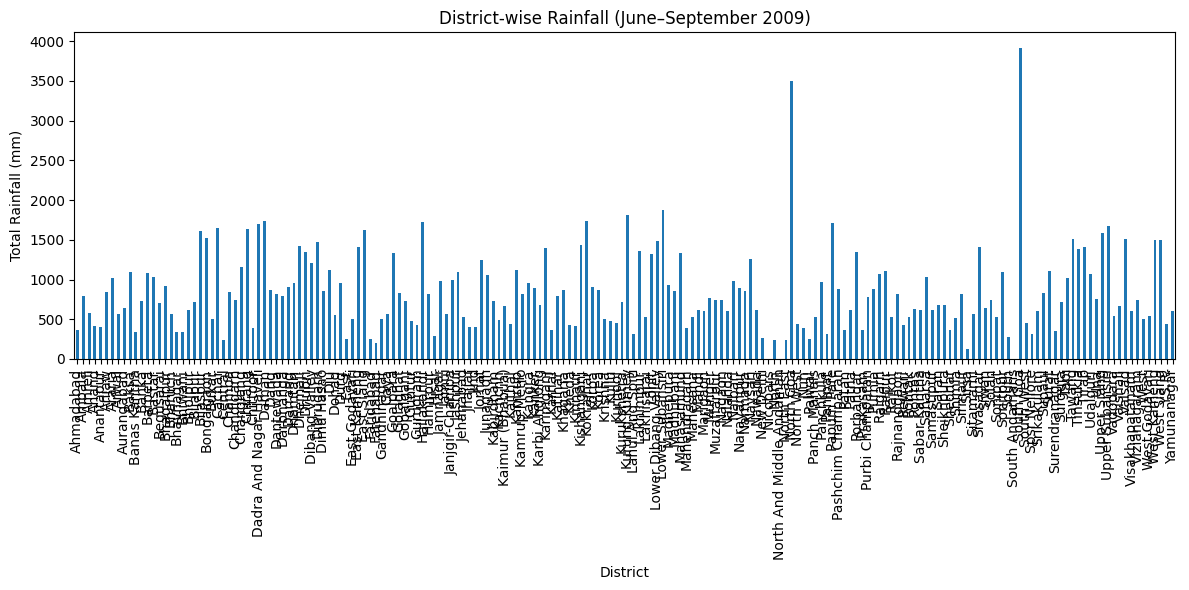

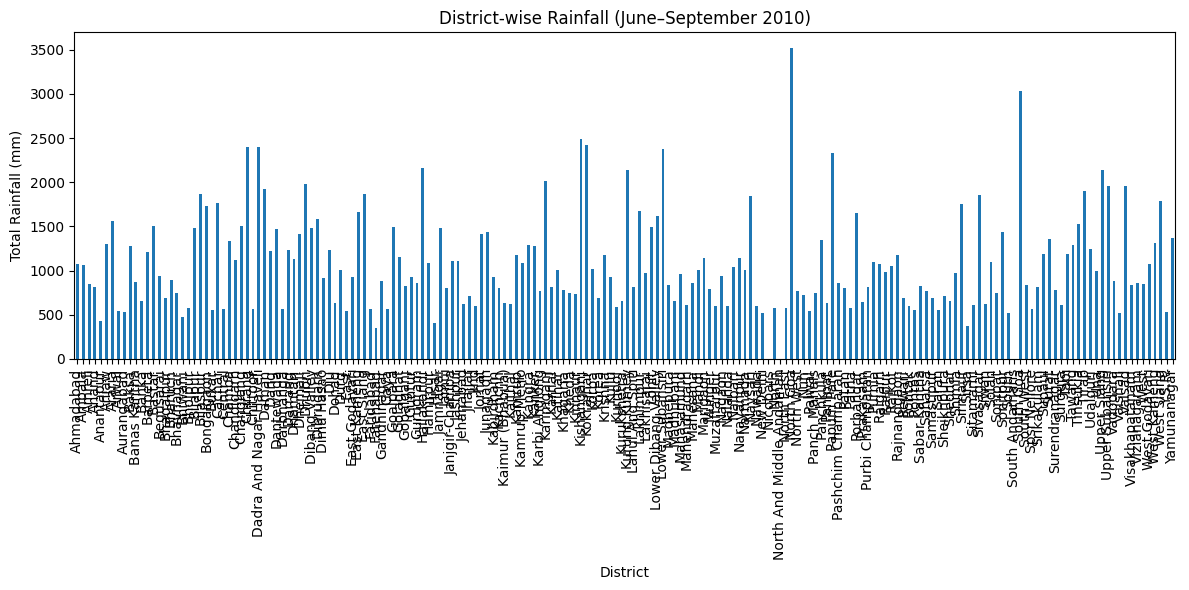

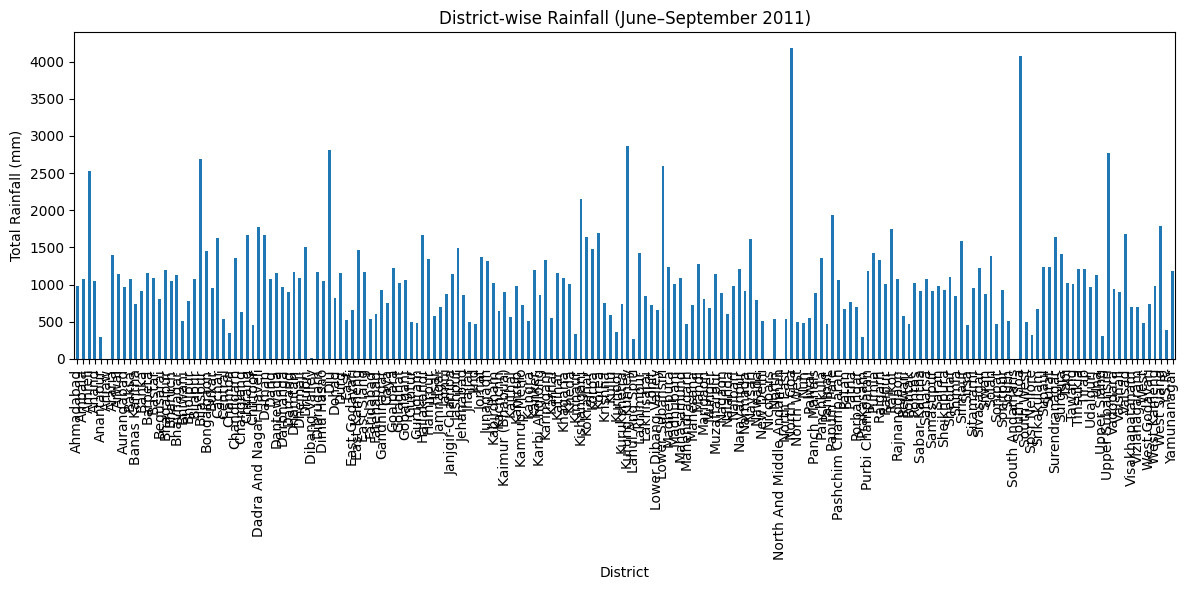

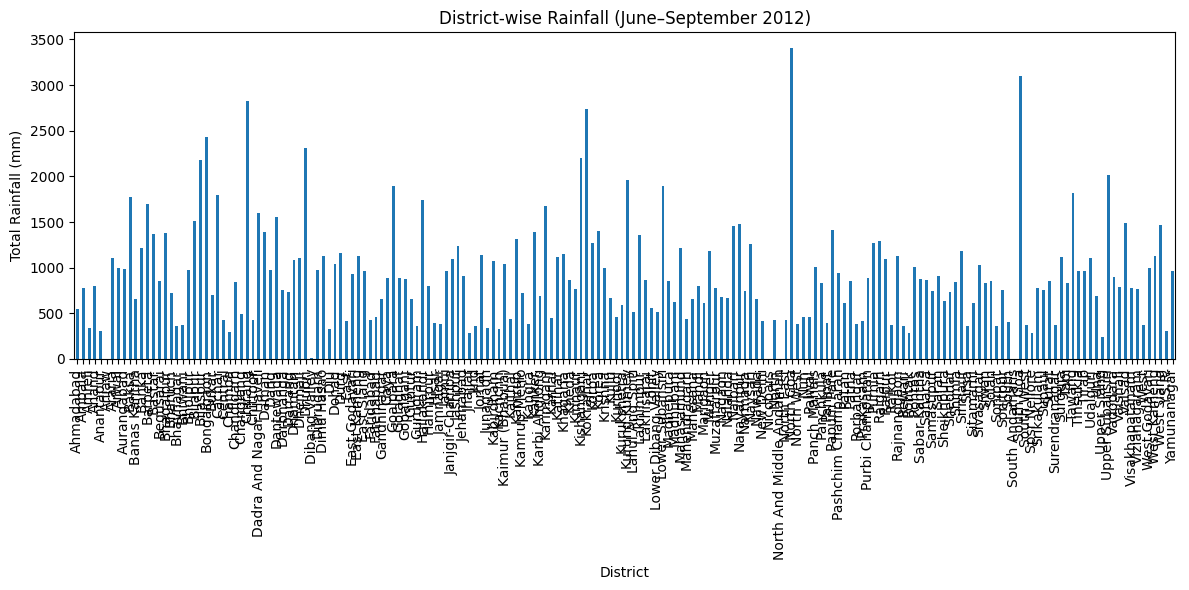

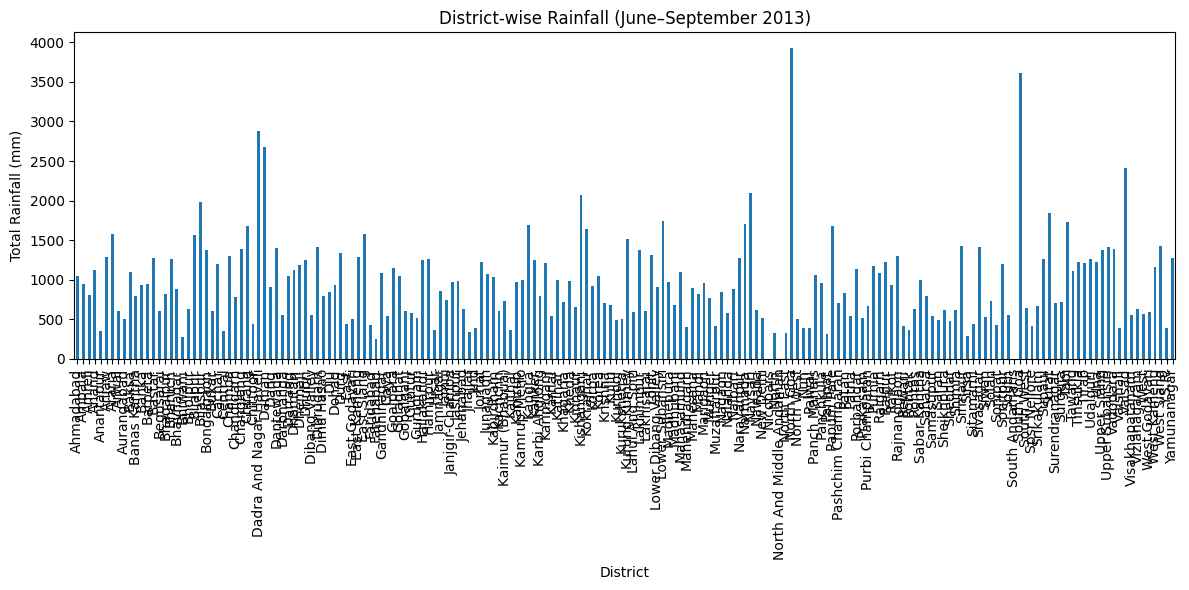

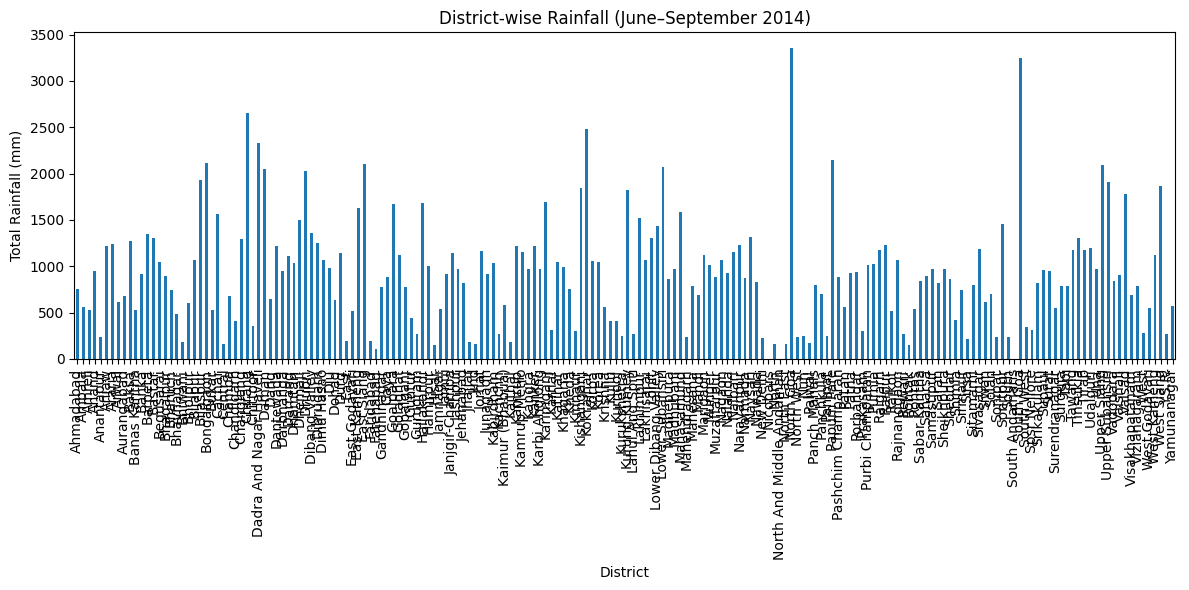

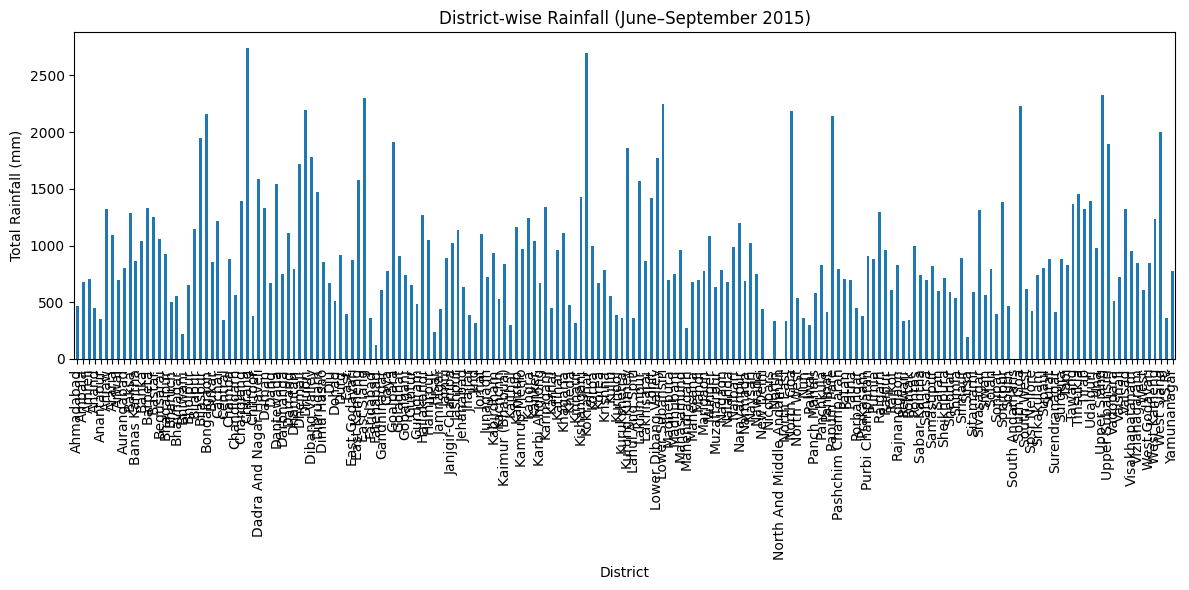

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'daily-rainfal.xlsx'
# Assuming the sheet name 'daily-rainfall-data-district-le' is correct based on your code
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure date is in datetime format
# Changed 'DATE' to 'date' to match the actual column name
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter months: June to September
# Changed 'DATE' to 'date'
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
# Changed 'DATE' to 'date'
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[(df['Year'] >= 2009) & (df['Year'] <= 2015)]

# Loop through each year and plot histograms
for year in range(2009, 2016):
    yearly_df = df[df['Year'] == year]

    # Group by district and sum rainfall
    # Ensure 'DISTRICT' and 'RAINFALL' are the correct column names if necessary
    # Replace 'District' and 'Actual_Rainfall' with the actual column names from your data
    district_rainfall = yearly_df.groupby('district_name')['actual'].sum() # <-- Corrected column names

    # Plot histogram
    plt.figure(figsize=(12, 6))
    district_rainfall.plot(kind='bar')
    plt.title(f'District-wise Rainfall (June–September {year})')
    plt.xlabel('District')
    plt.ylabel('Total Rainfall (mm)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Check for Districtwise rainfal

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'daily-rainfal.xlsx'
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure DATE column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter for June to September
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[df['Year'].between(2009, 2015)]

# Sort first by DISTRICT, then by DATE
df = df.sort_values(by=['Year', 'district_name', 'date'])

# Write to Excel: one sheet per year, with districts grouped
with pd.ExcelWriter('Districtwise_Rainfall_samya.xlsx') as writer:
    for year in range(2009, 2016):
        yearly_df = df[df['Year'] == year]
        yearly_df.to_excel(writer, sheet_name=str(year), index=False)


<ipython-input-17-cfca07d37bf8>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


Histogram analysis

Processing sheet: 2009


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


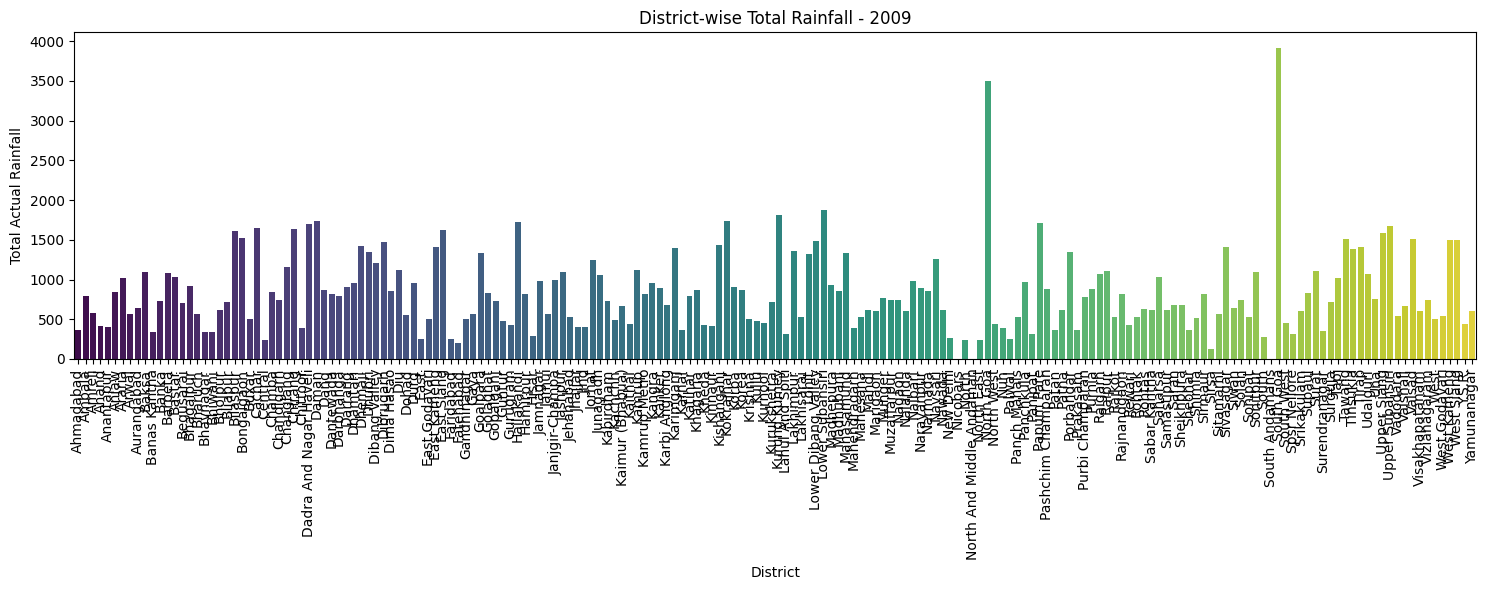

Processing sheet: 2010


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


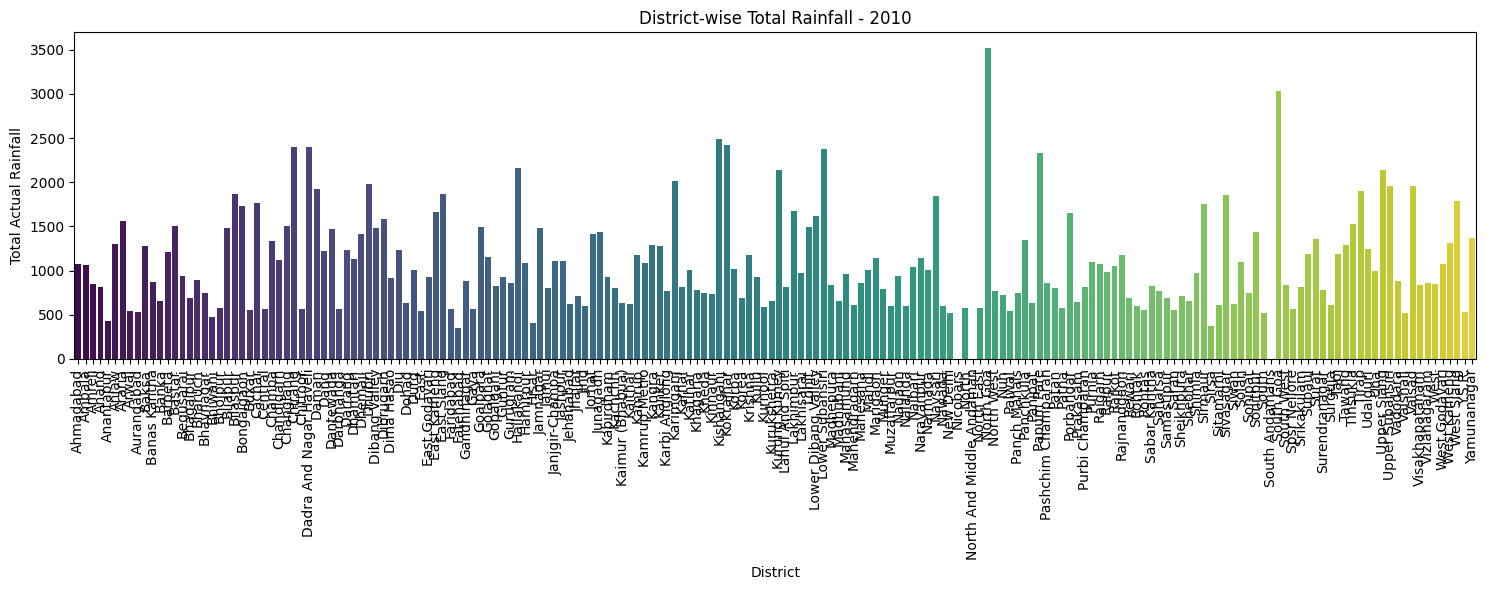

Processing sheet: 2011


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


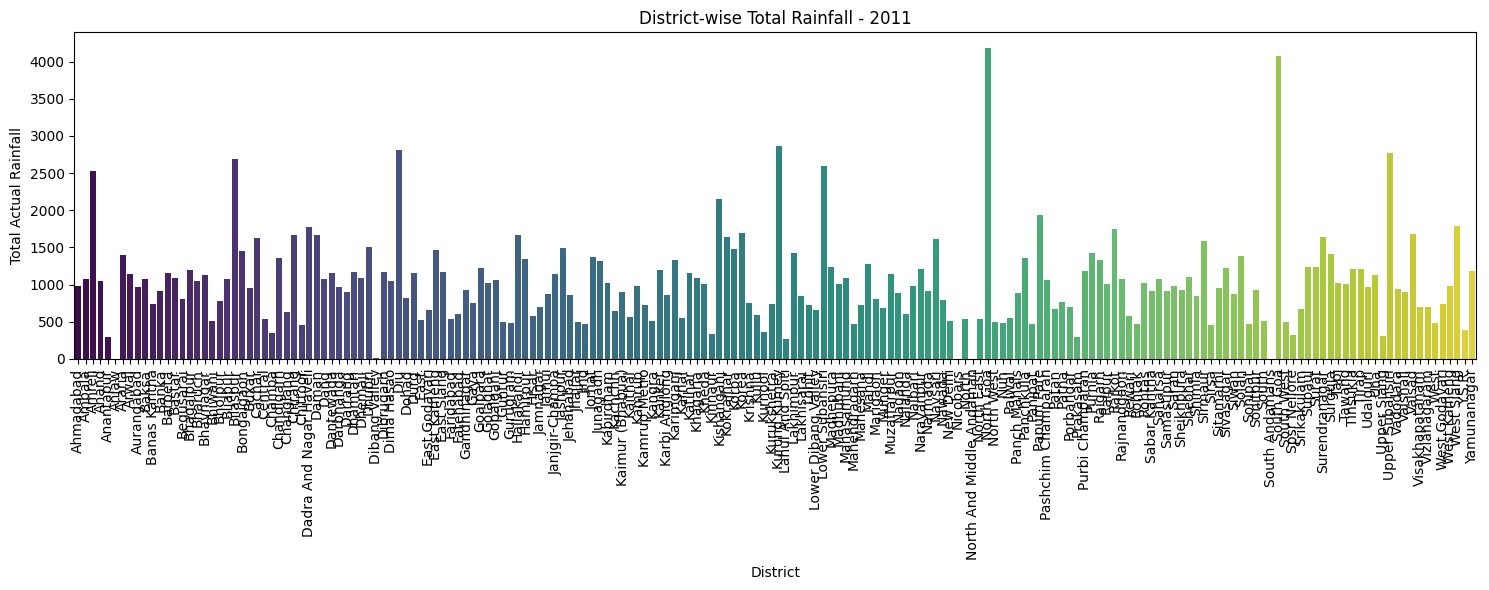

Processing sheet: 2012


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


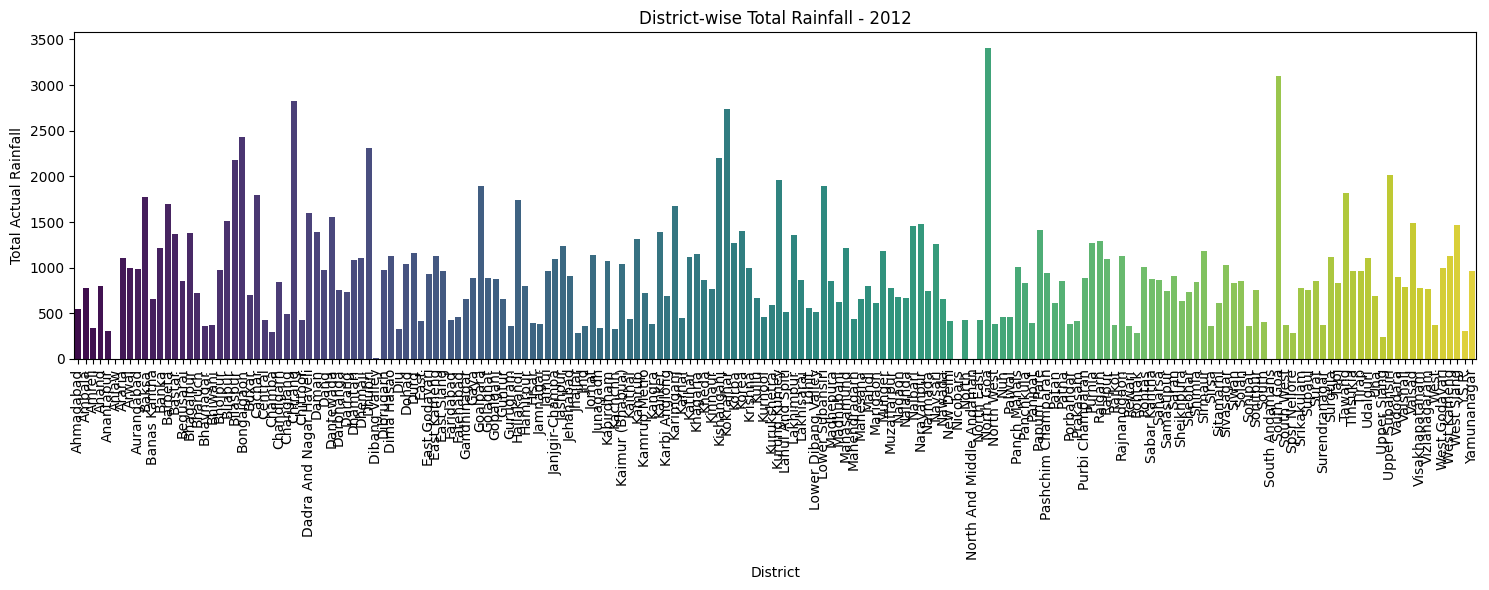

Processing sheet: 2013


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


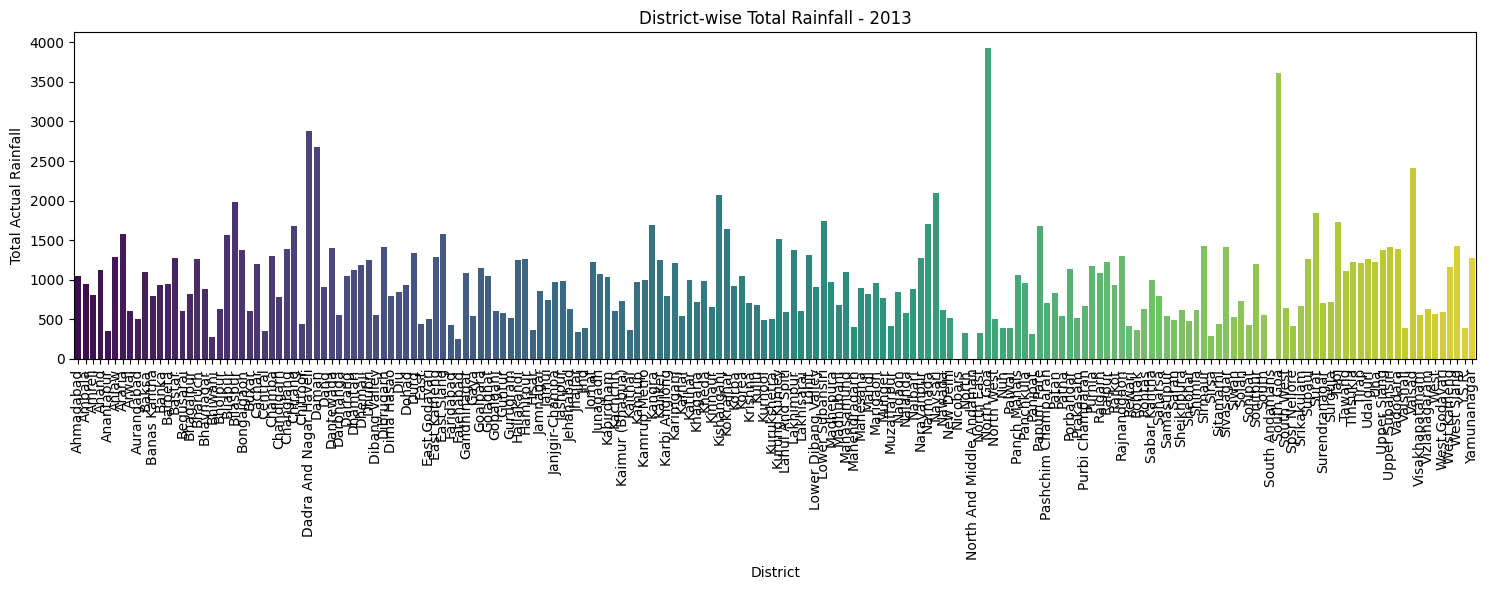

Processing sheet: 2014


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


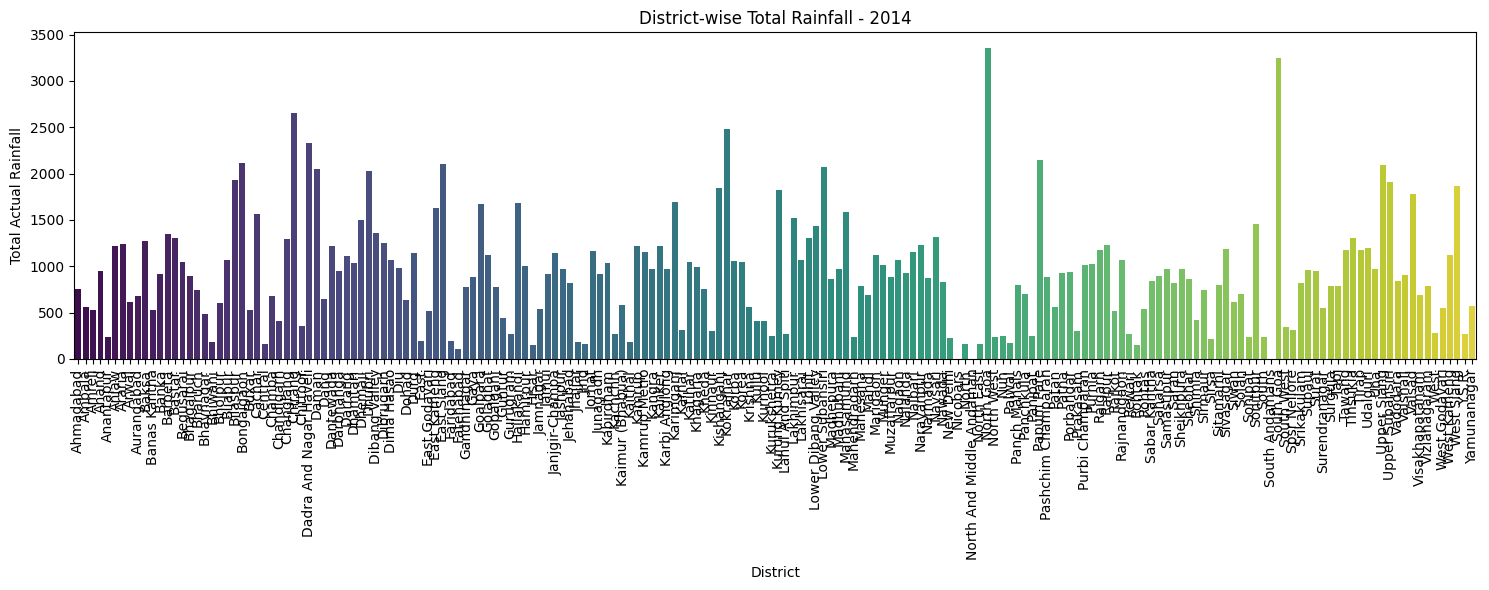

Processing sheet: 2015


<ipython-input-24-bcef92093c20>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


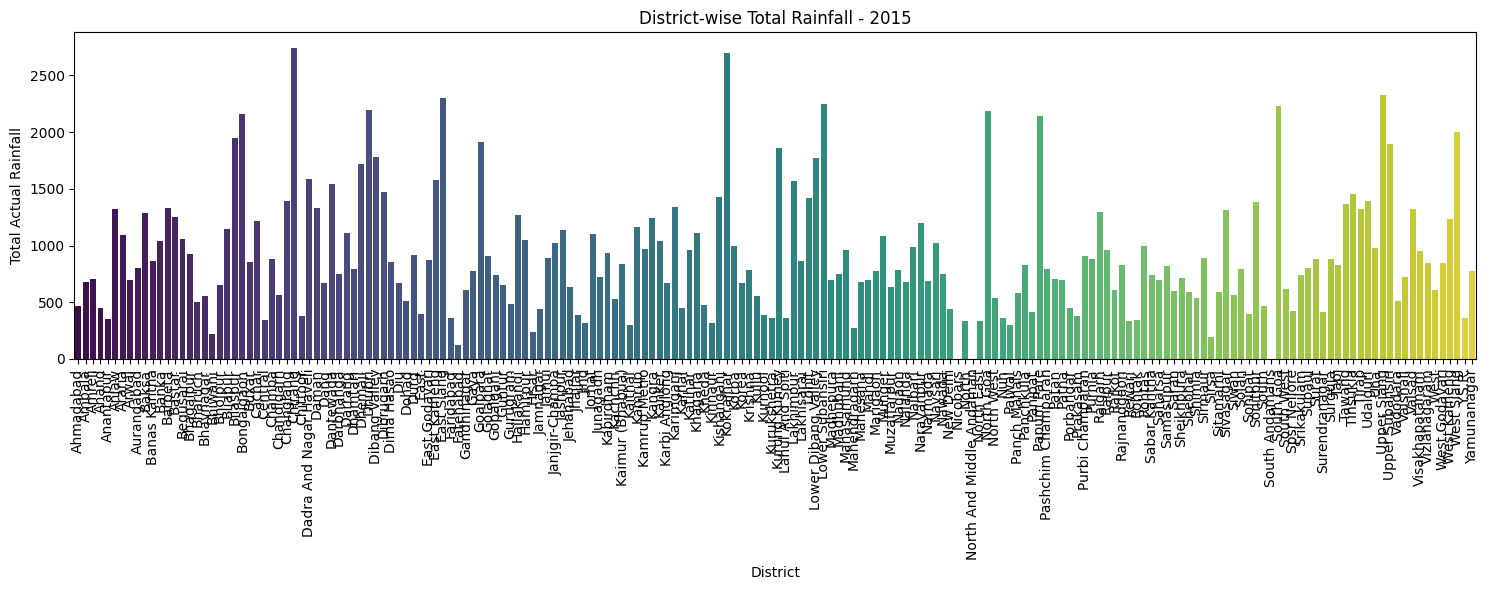

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all sheets into a dictionary
file_path = '/content/Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Iterate over each sheet
for sheet_name, df in all_sheets.items():
    print(f"Processing sheet: {sheet_name}")

    # Check if required columns exist
    if 'district_name' in df.columns and 'actual' in df.columns:
        # Group by district and sum rainfall
        district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()

        # Plotting
        plt.figure(figsize=(15,6))  # Increased width
        sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')

        plt.xlabel('District')
        plt.ylabel('Total Actual Rainfall')
        plt.title(f'District-wise Total Rainfall - {sheet_name}')
        plt.xticks(rotation=90)  # Vertical labels
        plt.tight_layout()
        plt.show()
    else:
        print(f"Columns 'district_name' or 'actual' not found in sheet {sheet_name}")

Districtwise lognormal fit


Processing sheet: 2009


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


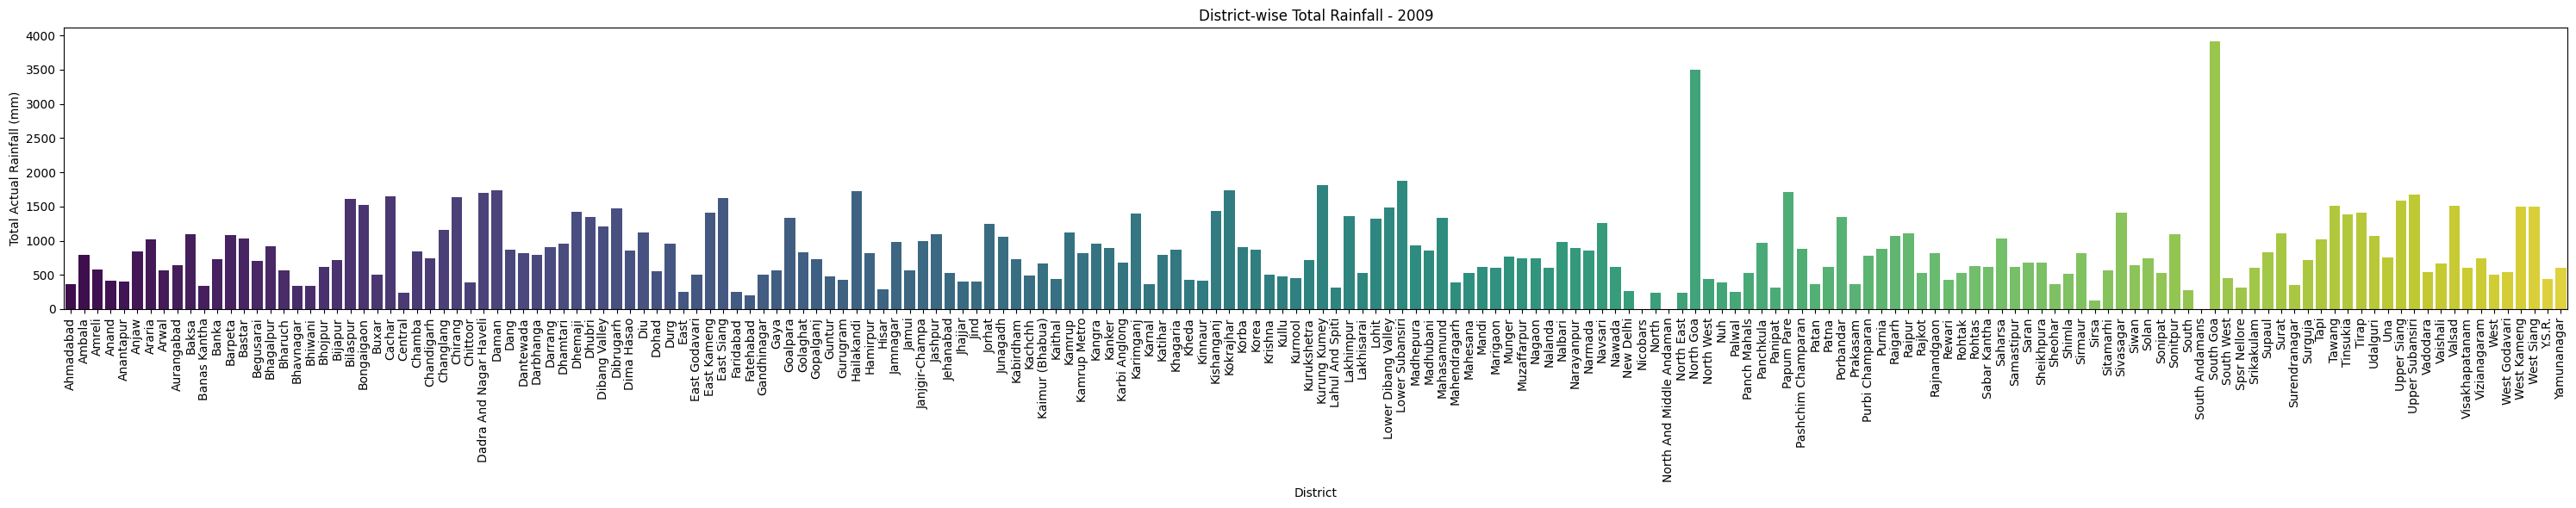


--- Distribution Analysis ---
Mean rainfall: 838.63 mm
Standard deviation: 515.34 mm
Skewness: 2.06
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


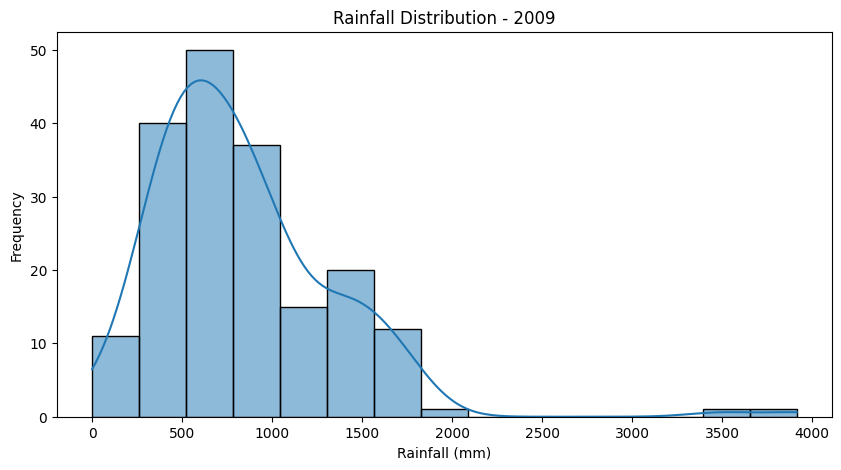


Processing sheet: 2010


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


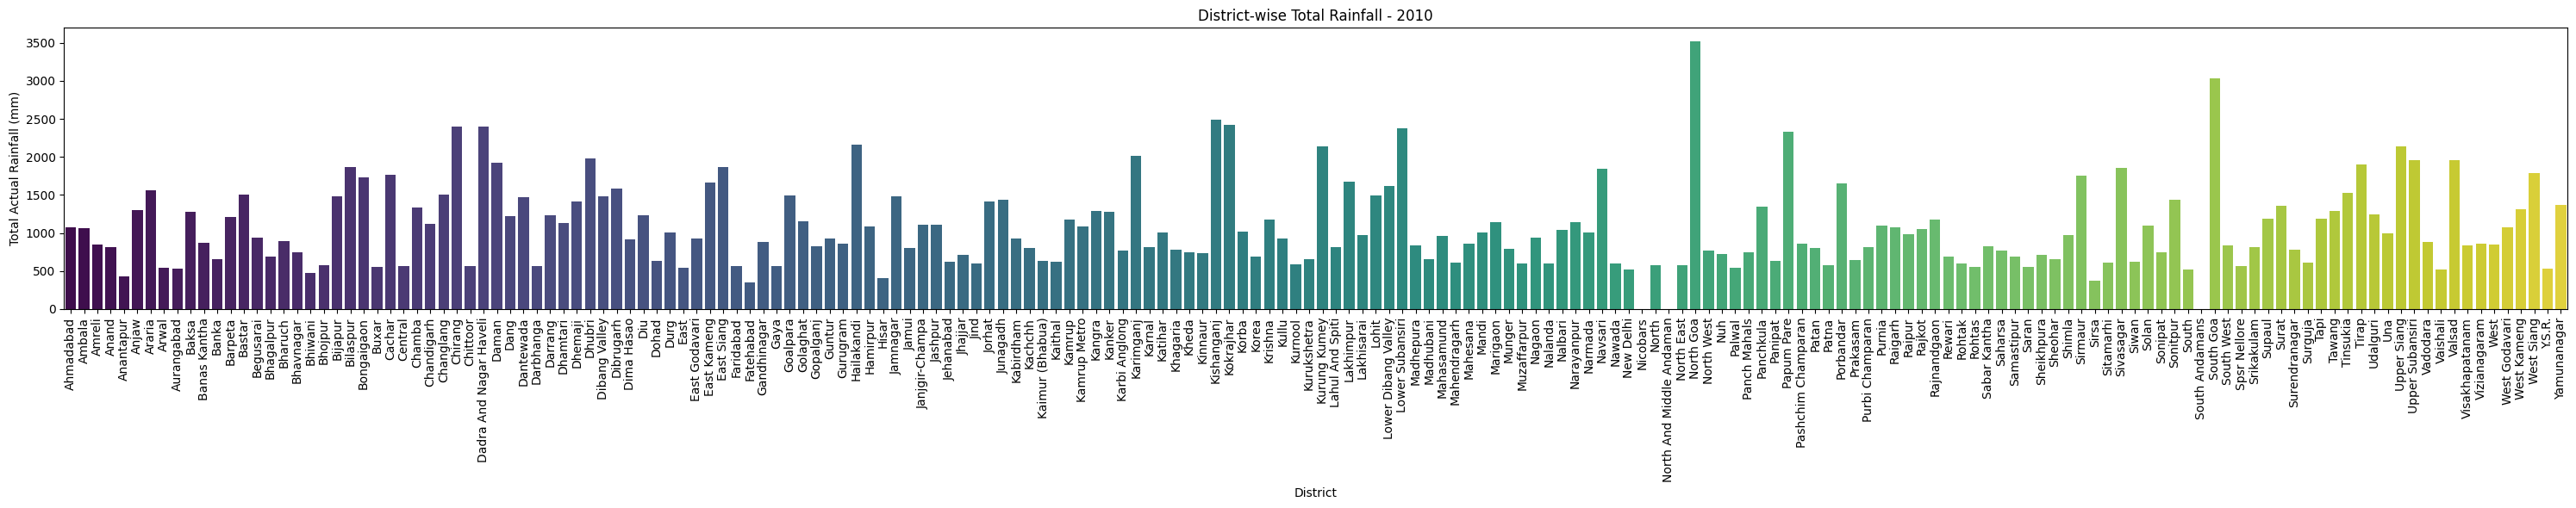


--- Distribution Analysis ---
Mean rainfall: 1071.61 mm
Standard deviation: 548.88 mm
Skewness: 1.25
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


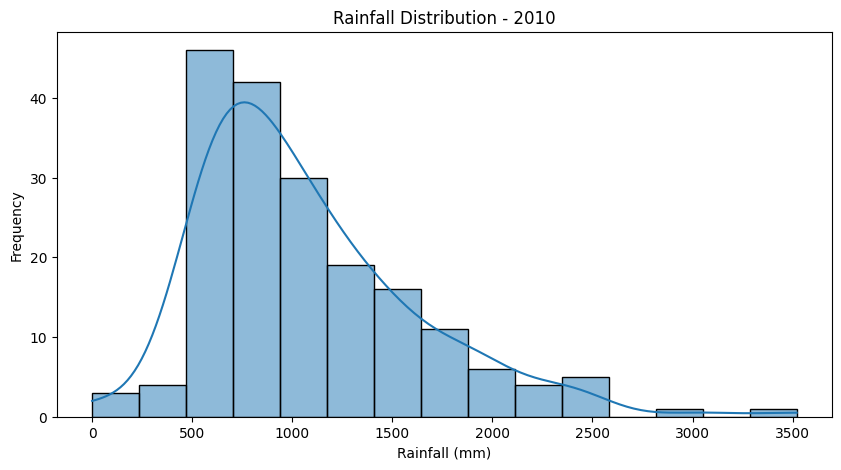


Processing sheet: 2011


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


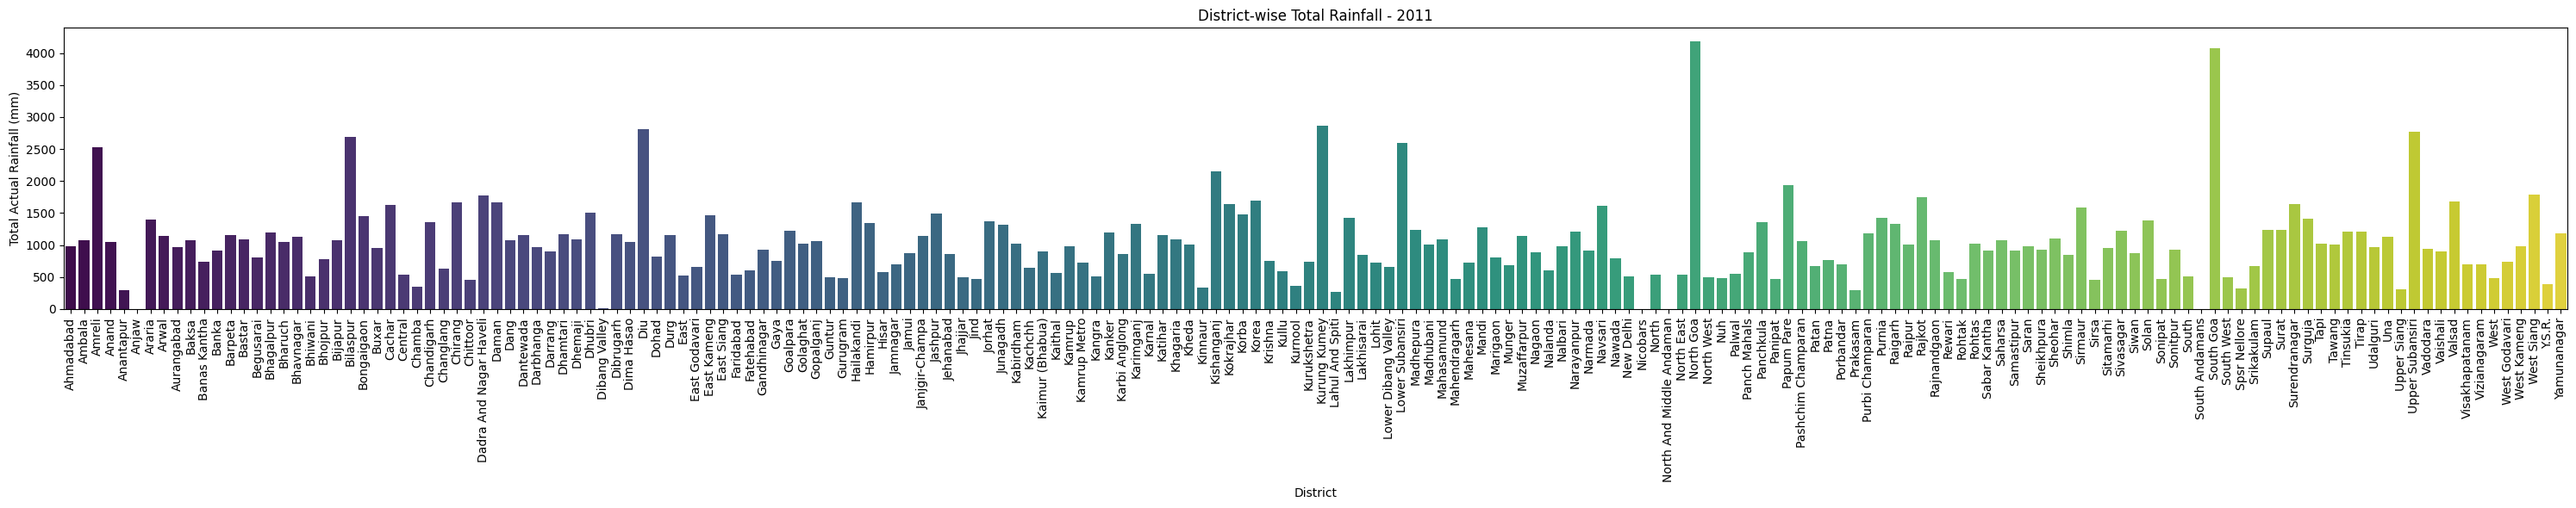


--- Distribution Analysis ---
Mean rainfall: 1027.07 mm
Standard deviation: 599.97 mm
Skewness: 2.03
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


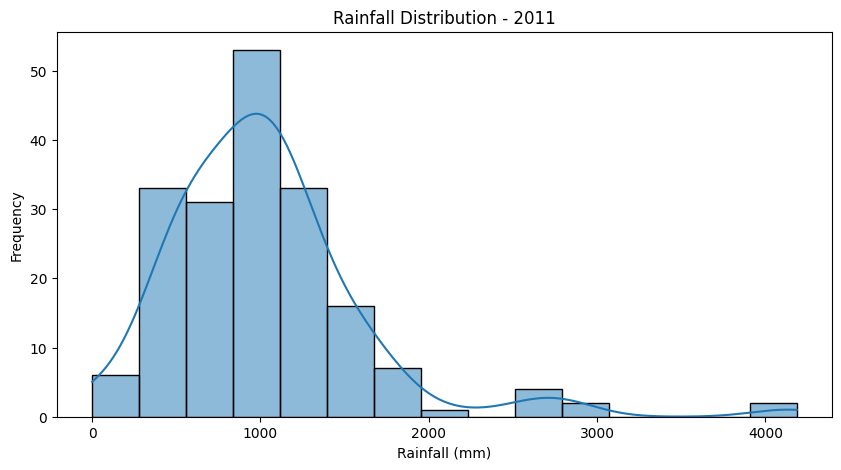


Processing sheet: 2012


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


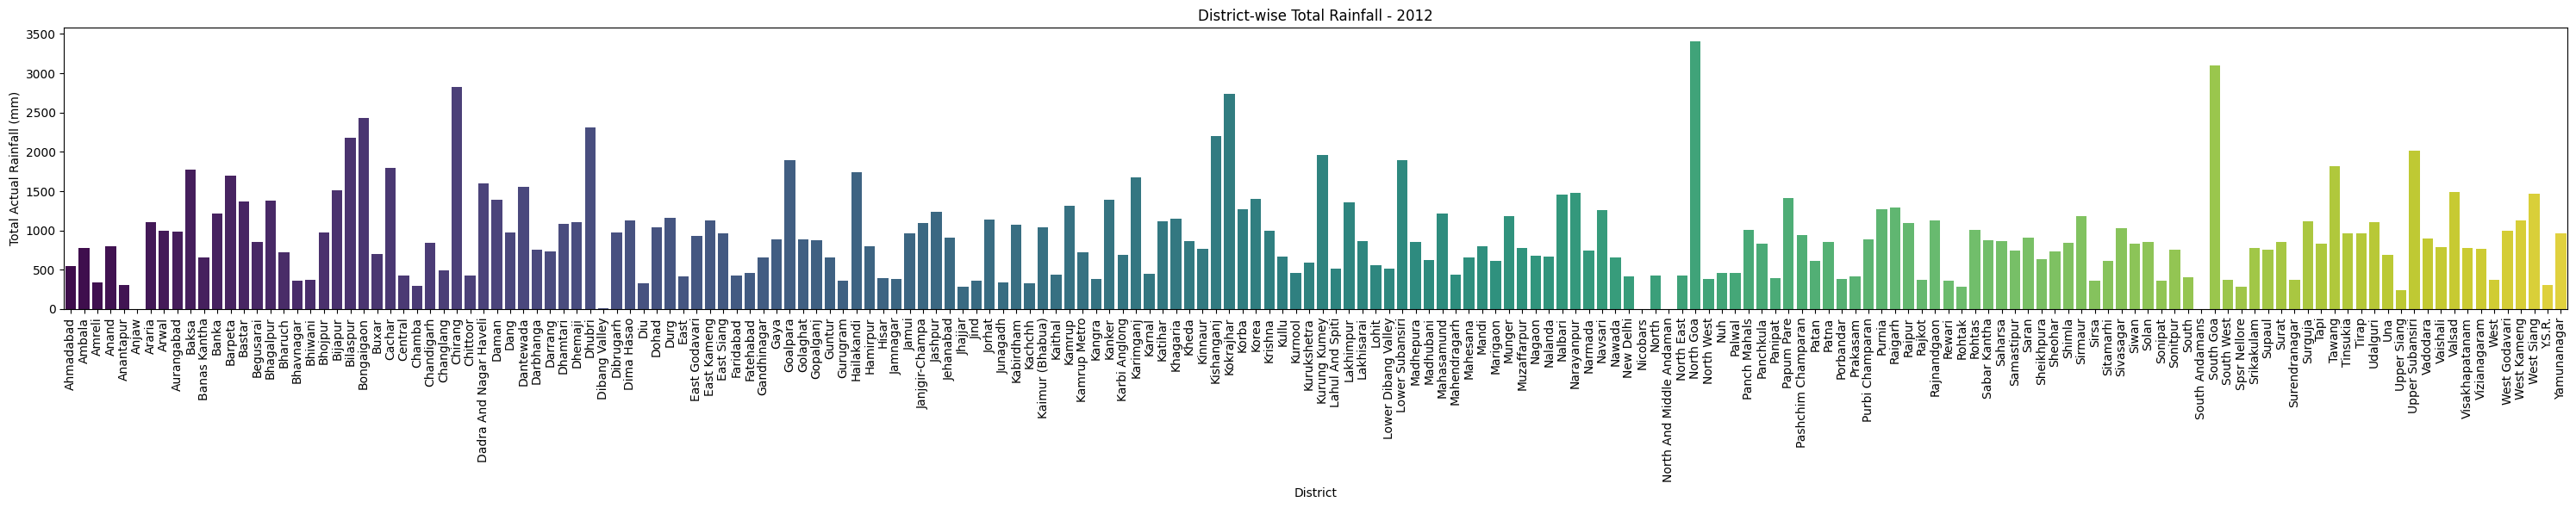


--- Distribution Analysis ---
Mean rainfall: 913.86 mm
Standard deviation: 561.38 mm
Skewness: 1.46
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


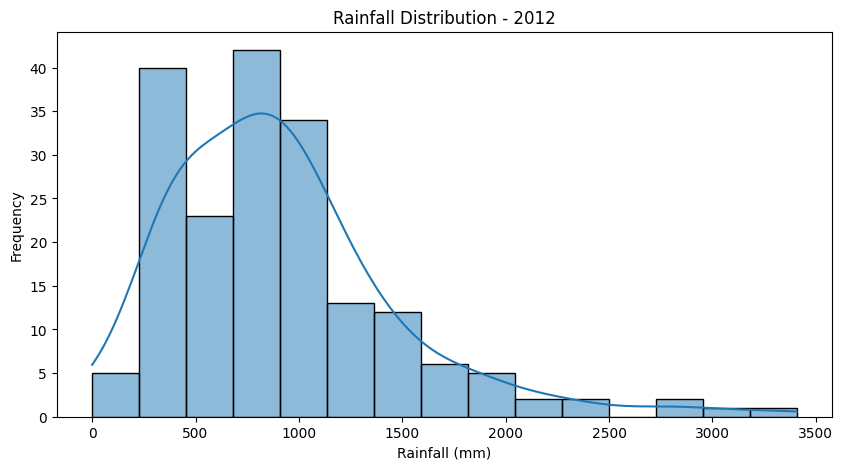


Processing sheet: 2013


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


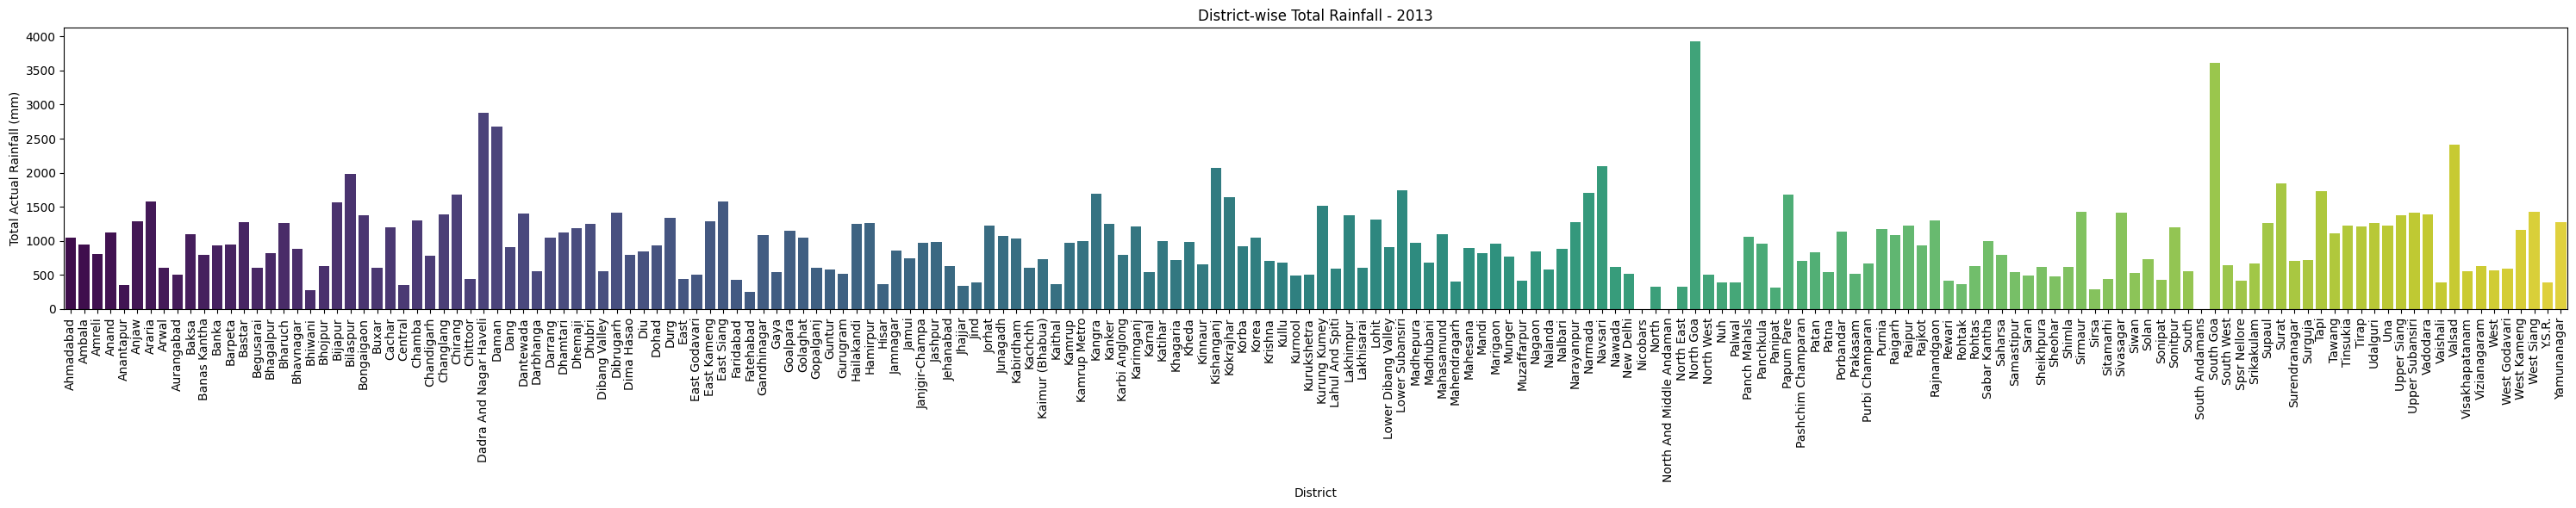


--- Distribution Analysis ---
Mean rainfall: 951.84 mm
Standard deviation: 554.10 mm
Skewness: 1.90
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


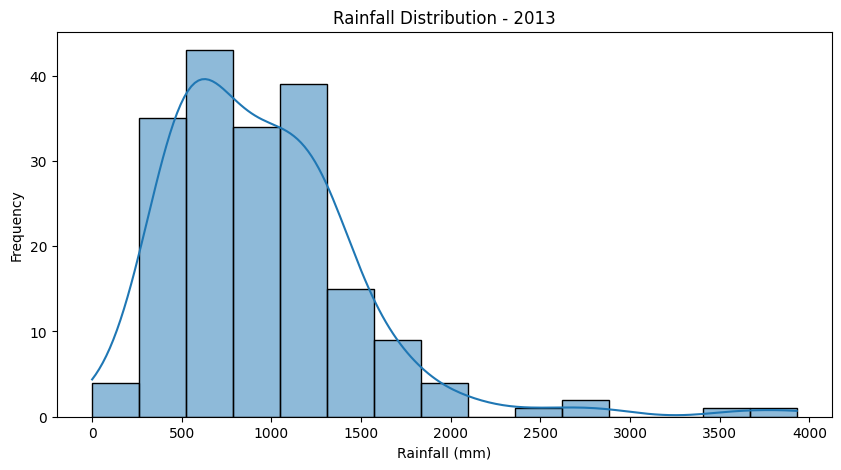


Processing sheet: 2014


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


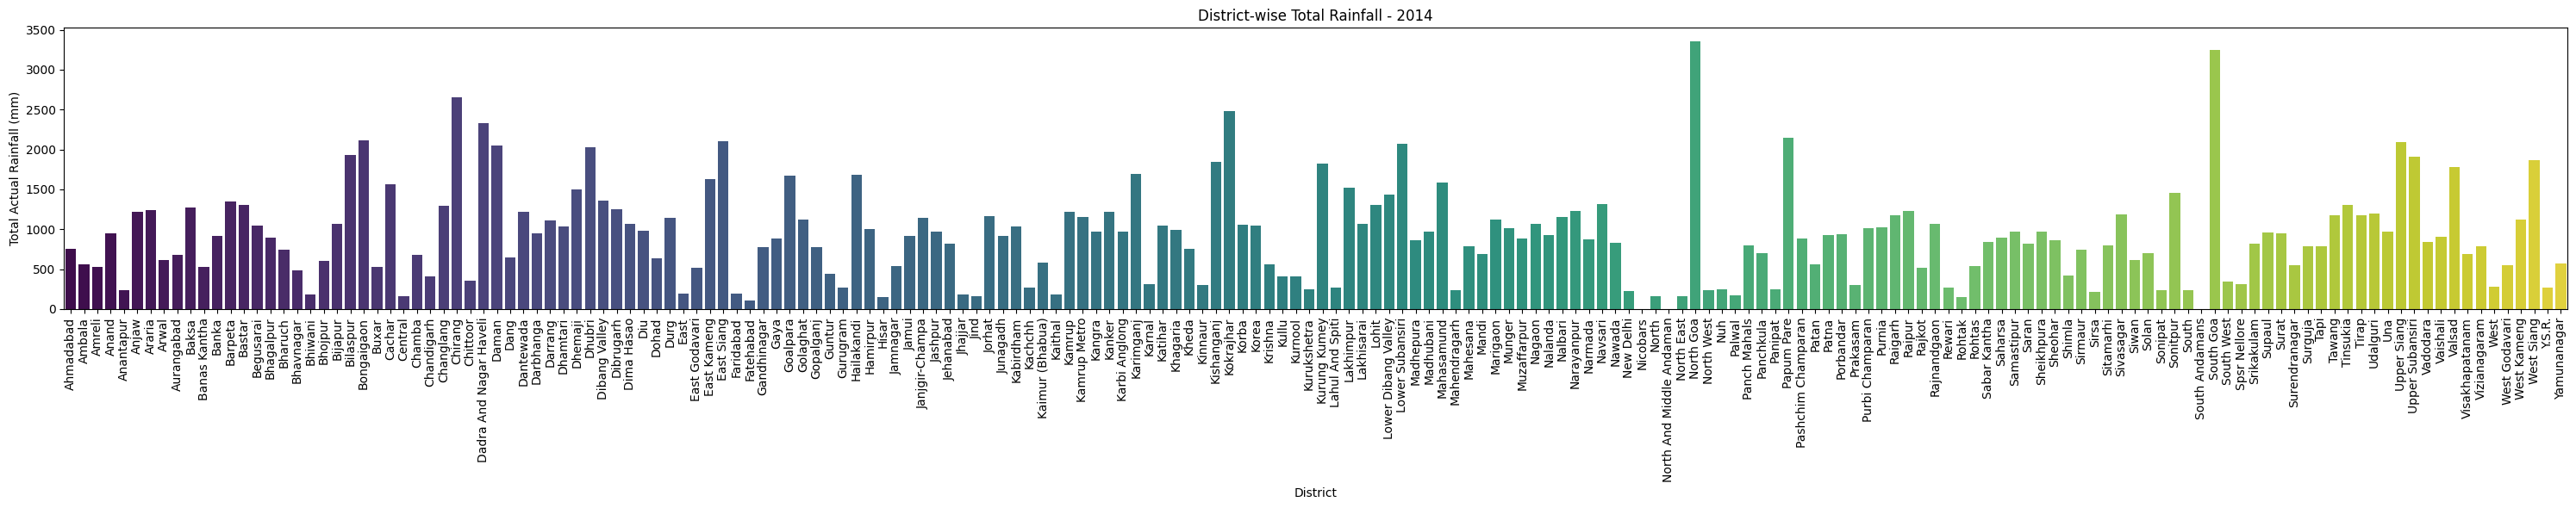


--- Distribution Analysis ---
Mean rainfall: 923.91 mm
Standard deviation: 587.06 mm
Skewness: 1.12
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


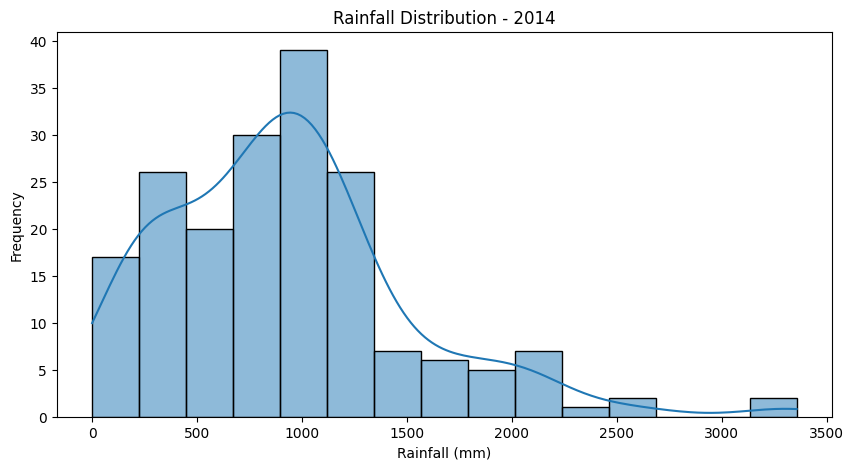


Processing sheet: 2015


<ipython-input-26-442597a7fb24>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


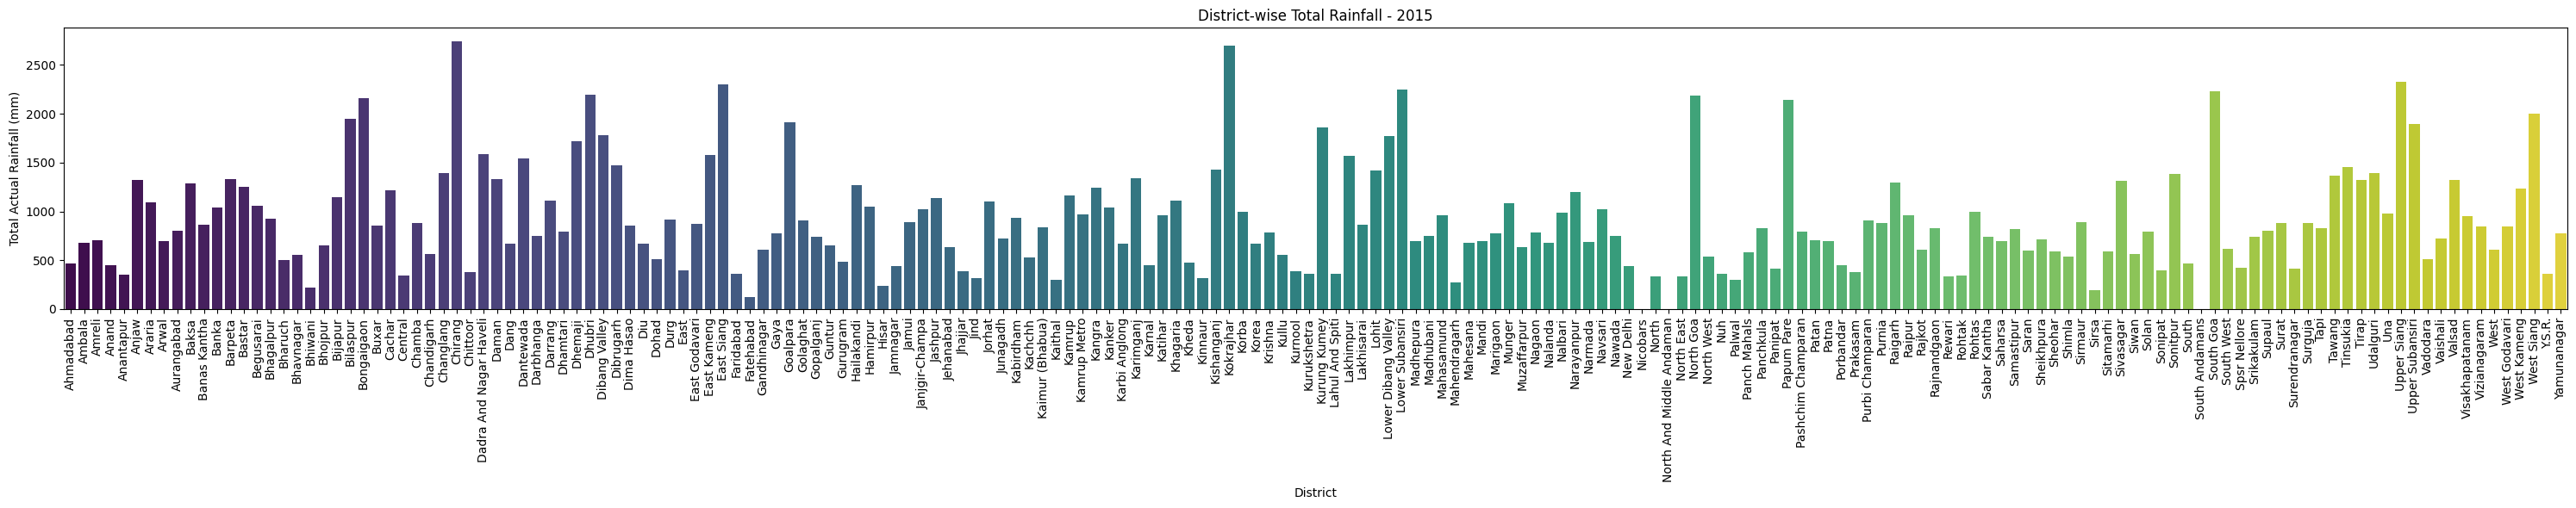


--- Distribution Analysis ---
Mean rainfall: 906.01 mm
Standard deviation: 525.19 mm
Skewness: 1.14
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


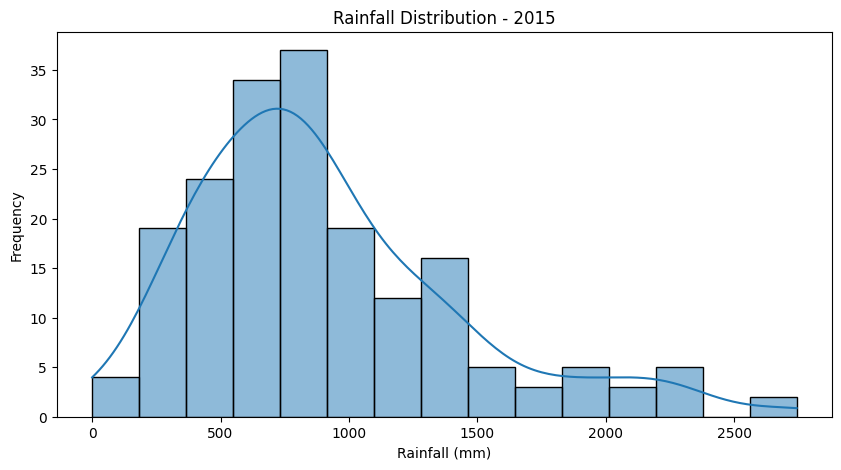

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load data
file_path = '/content/Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)

for sheet_name, df in all_sheets.items():
    print(f"\nProcessing sheet: {sheet_name}")

    if 'district_name' in df.columns and 'actual' in df.columns:
        district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()

        # Plotting
        plt.figure(figsize=(30, 6))
        sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')
        plt.xlabel('District')
        plt.ylabel('Total Actual Rainfall (mm)')
        plt.title(f'District-wise Total Rainfall - {sheet_name}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

        # Distribution Analysis
        rainfall_data = district_rainfall['actual']
        mean = np.mean(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)

        print("\n--- Distribution Analysis ---")
        print(f"Mean rainfall: {mean:.2f} mm")
        print(f"Standard deviation: {std:.2f} mm")
        print(f"Skewness: {skewness:.2f}")

        # Check for lognormality
        if skewness > 1:
            print("→ Data is right-skewed (possibly lognormal).")
            # Log-transform and check normality
            log_data = np.log(rainfall_data[rainfall_data > 0])  # Avoid log(0)
            _, p_value = stats.normaltest(log_data)
            if p_value > 0.05:
                print("→ Log-transformed data follows a normal distribution (confirms lognormality).")
            else:
                print("→ Log-transformed data does not follow a normal distribution.")
        else:
            print("→ Data is not strongly skewed (possibly normal or another distribution).")

        # Plot histogram
        plt.figure(figsize=(10, 5))
        sns.histplot(rainfall_data, kde=True, bins=15)
        plt.title(f'Rainfall Distribution - {sheet_name}')
        plt.xlabel('Rainfall (mm)')
        plt.ylabel('Frequency')
        plt.show()

    else:
        print(f"Columns 'district_name' or 'actual' not found in sheet {sheet_name}")

India analysis report

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Load all sheets and combine data
file_path = 'Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)
all_data = pd.concat(all_sheets.values(), ignore_index=True)

# Group by district for India-wide analysis
india_rainfall = all_data.groupby('district_name')['actual'].sum().reset_index()
rainfall_data = india_rainfall['actual']

# --- Create PDF Report ---
pdf_path = "India_Rainfall_Analysis_Report.pdf"
with PdfPages(pdf_path) as pdf:
    # --- Plot 1: Bar Plot (All Districts) ---
    plt.figure(figsize=(20, 8))
    sns.barplot(x='district_name', y='actual', data=india_rainfall, palette='viridis')
    plt.title('All-India District-wise Total Rainfall', fontsize=16)
    plt.xlabel('District', fontsize=12)
    plt.ylabel('Total Rainfall (mm)', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Plot 2: Histogram + KDE ---
    plt.figure(figsize=(10, 6))
    sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
    plt.title('Rainfall Distribution Across India', fontsize=16)
    plt.xlabel('Rainfall (mm)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    pdf.savefig()
    plt.close()

    # --- Plot 3: Q-Q Plot (Normality Check) ---
    plt.figure(figsize=(10, 6))
    stats.probplot(rainfall_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot: Rainfall vs Normal Distribution', fontsize=16)
    pdf.savefig()
    plt.close()

    # --- Plot 4: Top 10 & Bottom 10 Districts ---
    top_10 = india_rainfall.nlargest(10, 'actual')
    bottom_10 = india_rainfall.nsmallest(10, 'actual')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(x='actual', y='district_name', data=top_10, ax=ax1, palette='Blues_d')
    ax1.set_title('Top 10 Districts by Rainfall', fontsize=14)
    ax1.set_xlabel('Rainfall (mm)', fontsize=12)
    ax1.set_ylabel('District', fontsize=12)

    sns.barplot(x='actual', y='district_name', data=bottom_10, ax=ax2, palette='Reds_d')
    ax2.set_title('Bottom 10 Districts by Rainfall', fontsize=14)
    ax2.set_xlabel('Rainfall (mm)', fontsize=12)
    ax2.set_ylabel('')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Statistical Summary ---
    mean = np.mean(rainfall_data)
    median = np.median(rainfall_data)
    std = np.std(rainfall_data)
    skewness = stats.skew(rainfall_data)
    kurtosis = stats.kurtosis(rainfall_data)

    # Log-normality test
    log_data = np.log(rainfall_data[rainfall_data > 0])
    _, p_value_log = stats.normaltest(log_data)

    summary_text = (
        "--- All-India Rainfall Statistical Summary ---\n"
        f"Mean Rainfall: {mean:.2f} mm\n"
        f"Median Rainfall: {median:.2f} mm\n"
        f"Standard Deviation: {std:.2f} mm\n"
        f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
        f"Kurtosis: {kurtosis:.2f}\n\n"
        "--- Distribution Test ---\n"
    )
    if skewness > 1:
        summary_text += (
            "The data is strongly right-skewed, suggesting a lognormal distribution.\n"
            f"Log-Normality Test p-value: {p_value_log:.4f}\n"
            "→ p-value > 0.05 confirms lognormal distribution.\n"
        )
    else:
        summary_text += "The data does not strongly deviate from normality.\n"

    # Add summary to PDF
    plt.figure(figsize=(10, 4))
    plt.text(0.1, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
    plt.axis('off')
    pdf.savefig()
    plt.close()

print(f"Report generated successfully: {pdf_path}")

<ipython-input-27-0c54380460b7>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=india_rainfall, palette='viridis')
<ipython-input-27-0c54380460b7>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actual', y='district_name', data=top_10, ax=ax1, palette='Blues_d')
<ipython-input-27-0c54380460b7>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actual', y='district_name', data=bottom_10, ax=ax2, palette='Reds_d')


Report generated successfully: India_Rainfall_Analysis_Report.pdf


Report indian analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Output PDF report
pdf_path = "India_Rainfall_Analysis_Report.pdf"
with PdfPages(pdf_path) as pdf:
    for sheet_name, df in all_sheets.items():
        # Assuming 'actual' is the rainfall column
        # and 'district_name' is the district identifier
        # Adjust if your column names differ
        if 'district_name' in df.columns and 'actual' in df.columns:
            # Compute total rainfall per district
            district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
            rainfall_data = district_rainfall['actual']

            # --- Plot Histogram + KDE ---
            plt.figure(figsize=(10, 6))
            sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
            plt.title(f'Rainfall Distribution in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Statistical Summary ---
            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test on positive rainfall data
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan  # Not applicable if no positive data

            summary_text = (
                f"--- Statistical Summary for {sheet_name} ---\n"
                f"Number of districts: {len(rainfall_data)}\n"
                f"Mean Rainfall: {mean:.2f} mm\n"
                f"Median Rainfall: {median:.2f} mm\n"
                f"Standard Deviation: {std:.2f} mm\n"
                f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
                f"Kurtosis: {kurtosis:.2f}\n"
            )
            if skewness > 1:
                summary_text += (
                    f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                    f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                    "→ p-value > 0.05 confirms lognormal distribution.\n"
                )
            else:
                summary_text += "The data does not strongly deviate from normality.\n"

            # Add summary to PDF
            plt.figure(figsize=(10, 4))
            plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
            plt.axis('off')
            pdf.savefig()
            plt.close()
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

print(f"Report generated successfully: {pdf_path}")

Report generated successfully: India_Rainfall_Analysis_Report.pdf


Summary stat with comments on respective year

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Combine data from all sheets
all_data_list = []
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        all_data_list.append(df)

if not all_data_list:
    print("No valid data found in sheets.")
else:
    combined_df = pd.concat(all_data_list, ignore_index=True)
    # Compute total rainfall per district
    india_rainfall = combined_df.groupby('district_name')['actual'].sum().reset_index()
    rainfall_data = india_rainfall['actual']

    # Create PDF report
    pdf_path = "India_Rainfall_Analysis_Report.pdf"
    with PdfPages(pdf_path) as pdf:
        # --- Histogram + KDE for all India ---
        plt.figure(figsize=(10, 6))
        sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
        plt.title('All-India District-wise Total Rainfall Distribution', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Statistical Summary ---
        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test on positive data
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        summary_text = (
            "--- All-India Rainfall Statistical Summary ---\n"
            f"Number of districts: {len(rainfall_data)}\n"
            f"Mean Rainfall: {mean:.2f} mm\n"
            f"Median Rainfall: {median:.2f} mm\n"
            f"Standard Deviation: {std:.2f} mm\n"
            f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
            f"Kurtosis: {kurtosis:.2f}\n"
        )
        if skewness > 1:
            summary_text += (
                f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                "→ p-value > 0.05 confirms lognormal distribution.\n"
            )
        else:
            summary_text += "The data does not strongly deviate from normality.\n"

        # Add summary to PDF
        plt.figure(figsize=(10, 4))
        plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
        plt.axis('off')
        pdf.savefig()
        plt.close()

    print(f"All-India report generated successfully: {pdf_path}")

All-India report generated successfully: India_Rainfall_Analysis_Report.pdf


ALL INDIA REPORT DISTRIBUTION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Combine data from all sheets
all_data_list = []
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        all_data_list.append(df)

if not all_data_list:
    print("No valid data found in sheets.")
else:
    combined_df = pd.concat(all_data_list, ignore_index=True)
    # Compute total rainfall per district
    india_rainfall = combined_df.groupby('district_name')['actual'].sum().reset_index()
    rainfall_data = india_rainfall['actual']

    # Create PDF report
    pdf_path = "India_Level_Rainfall_Analysis_Report.pdf"
    with PdfPages(pdf_path) as pdf:
        # --- Histogram + KDE for all India ---
        plt.figure(figsize=(10, 6))
        sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
        plt.title('All-India District-wise Total Rainfall Distribution', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Boxplot for rainfall data ---
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=rainfall_data, color='lightgreen')
        plt.title('Boxplot of Total Rainfall Across Districts', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Statistical Summary ---
        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test on positive data
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        summary_text = (
            "--- All-India Rainfall Statistical Summary ---\n"
            f"Number of districts: {len(rainfall_data)}\n"
            f"Mean Rainfall: {mean:.2f} mm\n"
            f"Median Rainfall: {median:.2f} mm\n"
            f"Standard Deviation: {std:.2f} mm\n"
            f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
            f"Kurtosis: {kurtosis:.2f}\n"
        )
        if skewness > 1:
            summary_text += (
                f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                "→ p-value > 0.05 confirms lognormal distribution.\n"
            )
        else:
            summary_text += "The data does not strongly deviate from normality.\n"

        # Add summary to PDF
        plt.figure(figsize=(10, 4))
        plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
        plt.axis('off')
        pdf.savefig()
        plt.close()

    print(f"All-India report generated successfully: {pdf_path}")

All-India report generated successfully: India_Level_Rainfall_Analysis_Report.pdf


21 PAGES FOR EACH YEAR 2009 TO 2015

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Output PDF report
pdf_path = "India_Rainfall_Analysis(1)_Report.pdf"
with PdfPages(pdf_path) as pdf:
    for sheet_name, df in all_sheets.items():
        # Assuming 'actual' is the rainfall column
        # and 'district_name' is the district identifier
        # Adjust if your column names differ
        if 'district_name' in df.columns and 'actual' in df.columns:
            # Compute total rainfall per district
            district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
            rainfall_data = district_rainfall['actual']

            # --- Plot Histogram + KDE ---
            plt.figure(figsize=(10, 6))
            sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
            plt.title(f'Rainfall Distribution in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Plot Boxplot ---
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=rainfall_data, color='lightgreen')
            plt.title(f'Boxplot of Rainfall in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Statistical Summary ---
            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test on positive rainfall data
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan  # Not applicable if no positive data

            summary_text = (
                f"--- Statistical Summary for {sheet_name} ---\n"
                f"Number of districts: {len(rainfall_data)}\n"
                f"Mean Rainfall: {mean:.2f} mm\n"
                f"Median Rainfall: {median:.2f} mm\n"
                f"Standard Deviation: {std:.2f} mm\n"
                f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
                f"Kurtosis: {kurtosis:.2f}\n"
            )
            if skewness > 1:
                summary_text += (
                    f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                    f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                    "→ p-value > 0.05 confirms lognormal distribution.\n"
                )
            else:
                summary_text += "The data does not strongly deviate from normality.\n"

            # Add summary to PDF
            plt.figure(figsize=(10, 4))
            plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center')
            plt.axis('off')
            pdf.savefig()
            plt.close()
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

print(f"Report generated successfully: {pdf_path}")

Report generated successfully: India_Rainfall_Analysis(1)_Report.pdf


Line graph of mu and sigma(2009-2015)

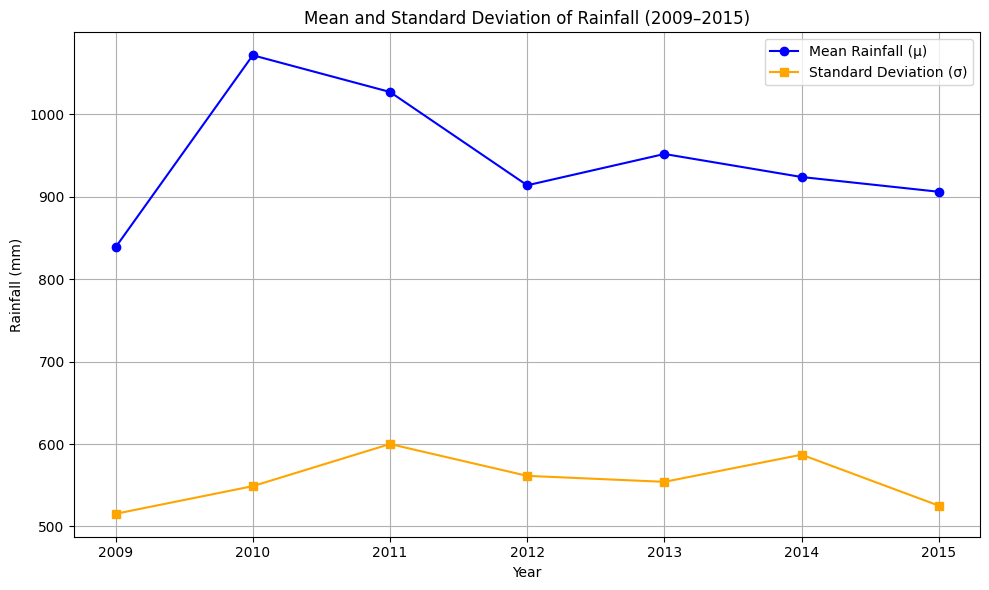

In [ ]:
import matplotlib.pyplot as plt

# Years from the document
years = [2009, 2010, 2011, 2012, 2013, 2014, 2015]

# Extracted mean (mu) and standard deviation (sigma) from the report
mu = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01]
sigma = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, mu, marker='o', label='Mean Rainfall (μ)', color='blue')
plt.plot(years, sigma, marker='s', label='Standard Deviation (σ)', color='orange')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.title('Mean and Standard Deviation of Rainfall (2009–2015)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Indian Rainfall analysis report from 2016 to 2024 all in one

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Combine data from all sheets
all_data_list = []
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        all_data_list.append(df)

if not all_data_list:
    print("No valid data found in sheets.")
else:
    combined_df = pd.concat(all_data_list, ignore_index=True)
    # Compute total rainfall per district
    india_rainfall = combined_df.groupby('district_name')['actual'].sum().reset_index()
    rainfall_data = india_rainfall['actual']

    # Create PDF report
    pdf_path = "India_Rainfall_Analysis_Report(2016-2024).pdf"
    with PdfPages(pdf_path) as pdf:
        # --- Histogram + KDE for all India ---
        plt.figure(figsize=(10, 6))
        sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
        plt.title('All-India District-wise Total Rainfall Distribution', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Statistical Summary ---
        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test on positive data
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        summary_text = (
            "--- All-India Rainfall Statistical Summary ---\n"
            f"Number of districts: {len(rainfall_data)}\n"
            f"Mean Rainfall: {mean:.2f} mm\n"
            f"Median Rainfall: {median:.2f} mm\n"
            f"Standard Deviation: {std:.2f} mm\n"
            f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
            f"Kurtosis: {kurtosis:.2f}\n"
        )
        if skewness > 1:
            summary_text += (
                f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                "→ p-value > 0.05 confirms lognormal distribution.\n"
            )
        else:
            summary_text += "The data does not strongly deviate from normality.\n"

        # Add summary to PDF
        plt.figure(figsize=(10, 4))
        plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
        plt.axis('off')
        pdf.savefig()
        plt.close()

    print(f"All-India report generated successfully: {pdf_path}")

All-India report generated successfully: India_Rainfall_Analysis_Report(2016-2024).pdf


Detailed report for each year starting from 2016 to 2024

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Output PDF report
pdf_path = "India_Rainfall_Analysis(1)_Report(2016-2024 each).pdf"
with PdfPages(pdf_path) as pdf:
    for sheet_name, df in all_sheets.items():
        # Assuming 'actual' is the rainfall column
        # and 'district_name' is the district identifier
        # Adjust if your column names differ
        if 'district_name' in df.columns and 'actual' in df.columns:
            # Compute total rainfall per district
            district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
            rainfall_data = district_rainfall['actual']

            # --- Plot Histogram + KDE ---
            plt.figure(figsize=(10, 6))
            sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
            plt.title(f'Rainfall Distribution in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Plot Boxplot ---
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=rainfall_data, color='lightgreen')
            plt.title(f'Boxplot of Rainfall in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Statistical Summary ---
            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test on positive rainfall data
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan  # Not applicable if no positive data

            summary_text = (
                f"--- Statistical Summary for {sheet_name} ---\n"
                f"Number of districts: {len(rainfall_data)}\n"
                f"Mean Rainfall: {mean:.2f} mm\n"
                f"Median Rainfall: {median:.2f} mm\n"
                f"Standard Deviation: {std:.2f} mm\n"
                f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
                f"Kurtosis: {kurtosis:.2f}\n"
            )
            if skewness > 1:
                summary_text += (
                    f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                    f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                    "→ p-value > 0.05 confirms lognormal distribution.\n"
                )
            else:
                summary_text += "The data does not strongly deviate from normality.\n"

            # Add summary to PDF
            plt.figure(figsize=(10, 4))
            plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center')
            plt.axis('off')
            pdf.savefig()
            plt.close()
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

print(f"Report generated successfully: {pdf_path}")

Report generated successfully: India_Rainfall_Analysis(1)_Report(2016-2024 each).pdf


Mean and standard deviation graph fro 2016 to 2024

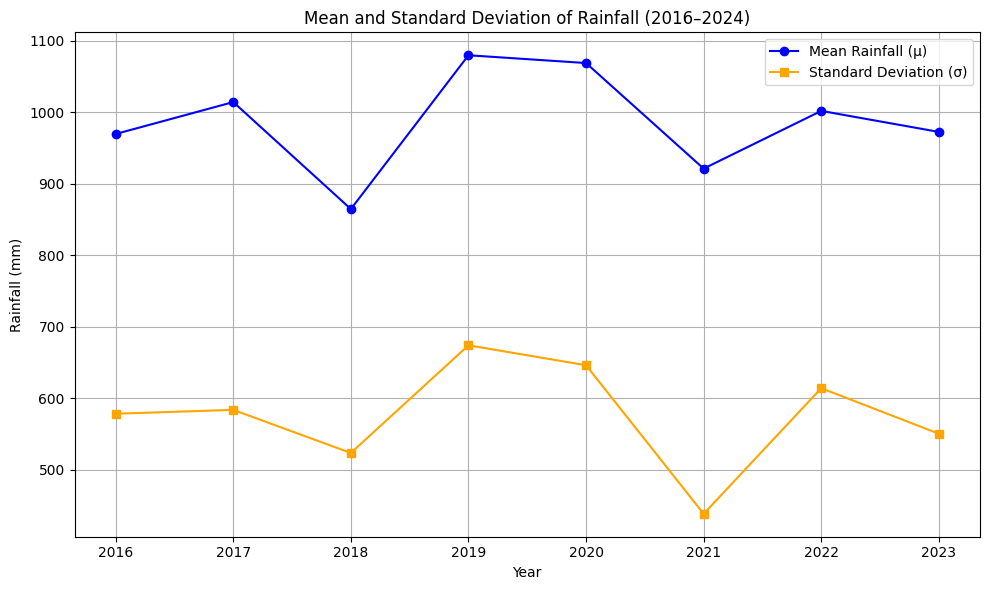

In [ ]:
# Re-importing required libraries after kernel reset
import matplotlib.pyplot as plt

# Extended years from 2016 to 2024
years_extended = list(range(2016, 2024))

# Extracted mu and sigma from the report
mu_extended = [969.49, 1014.12, 864.52, 1079.57, 1068.68, 921.07, 1001.76, 972.39]
sigma_extended = [578.35, 583.72, 523.49, 674.01, 646.14, 438.43, 614.03, 550.42]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years_extended, mu_extended, marker='o', label='Mean Rainfall (μ)', color='blue')
plt.plot(years_extended, sigma_extended, marker='s', label='Standard Deviation (σ)', color='orange')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.title('Mean and Standard Deviation of Rainfall (2016–2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Predicting the mean and standard deviation of 2021 to 2024 using the data from 2009 to 2020

In [ ]:
import pandas as pd

# Observed mean and standard deviation from 2009 to 2020 (12 values)
mu_yearly = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01,
             969.49, 1014.12, 864.52, 1079.57, 1068.68]

sigma_yearly = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19,
                578.35, 583.72, 523.49, 674.01, 646.14]

# Predict for 2021 (12 obs), 2022 (13 obs), 2023 (14 obs), 2024 (15 obs)
# We'll simulate adding new observations (repeating last value) for years beyond 2020
predicted_mu = []
predicted_sigma = []

# Start with available data up to 2020
for i in range(12, 16):  # Span = 12 to 15
    # Simulate adding latest known values to extend data (use real if available)
    mu_input = mu_yearly[:i] if i <= len(mu_yearly) else mu_yearly + predicted_mu[:i - len(mu_yearly)]
    sigma_input = sigma_yearly[:i] if i <= len(sigma_yearly) else sigma_yearly + predicted_sigma[:i - len(sigma_yearly)]

    mu_series = pd.Series(mu_input)
    sigma_series = pd.Series(sigma_input)

    mu_ema = mu_series.ewm(span=i, adjust=False).mean().iloc[-1]
    sigma_ema = sigma_series.ewm(span=i, adjust=False).mean().iloc[-1]

    predicted_mu.append(mu_ema)
    predicted_sigma.append(sigma_ema)

# Display predictions
for year, mu_val, sigma_val in zip(range(2021, 2025), predicted_mu, predicted_sigma):
    print(f"{year} - Predicted Mean: {mu_val:.2f} mm, Predicted Std Dev: {sigma_val:.2f} mm")


2021 - Predicted Mean: 965.87 mm, Predicted Std Dev: 580.64 mm
2022 - Predicted Mean: 962.00 mm, Predicted Std Dev: 578.27 mm
2023 - Predicted Mean: 958.78 mm, Predicted Std Dev: 576.34 mm
2024 - Predicted Mean: 956.03 mm, Predicted Std Dev: 574.72 mm


Comparing the percentage error in mean and standard deviation

In [ ]:
import pandas as pd

# EMA predicted mean and std dev for 2021–2024
ema_mu = [predicted_mu[0], predicted_mu[1], predicted_mu[2], predicted_mu[3]]
ema_sigma = [predicted_sigma[0], predicted_sigma[1], predicted_sigma[2], predicted_sigma[3]]

# Observed values from report
observed_mu = [921.07, 1001.76, 972.39, 0.00]
observed_sigma = [438.43, 614.03, 550.42, 0.00]

# Compare
print("Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ")
for i, year in enumerate(range(2021, 2025)):
    mu_obs = observed_mu[i]
    mu_pred = ema_mu[i]
    sigma_obs = observed_sigma[i]
    sigma_pred = ema_sigma[i]

    mu_error = abs(mu_pred - mu_obs) / mu_obs * 100 if mu_obs != 0 else float('nan')
    sigma_error = abs(sigma_pred - sigma_obs) / sigma_obs * 100 if sigma_obs != 0 else float('nan')

    print(f"{year} | {mu_obs:.2f}      | {mu_pred:.2f}      | {mu_error:.2f}%     | "
          f"{sigma_obs:.2f}     | {sigma_pred:.2f}      | {sigma_error:.2f}%")


Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ
2021 | 921.07      | 965.87      | 4.86%     | 438.43     | 580.64      | 32.44%
2022 | 1001.76      | 962.00      | 3.97%     | 614.03     | 578.27      | 5.82%
2023 | 972.39      | 958.78      | 1.40%     | 550.42     | 576.34      | 4.71%
2024 | 0.00      | 956.03      | nan%     | 0.00     | 574.72      | nan%


Using Exponential Moving average to predict for 2025 to 2027

In [ ]:
import pandas as pd

# Step 1: Historical data from 2009 to 2023 (15 years total)
mu_yearly = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01,
             969.49, 1014.12, 864.52, 1079.57, 1068.68, 921.07, 1001.76, 972.39]

sigma_yearly = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19,
                578.35, 583.72, 523.49, 674.01, 646.14, 438.43, 614.03, 550.42]

# Step 2: Compute EMA predictions for 2021–2023
predicted_mu = []
predicted_sigma = []

for i in range(12, 15):  # for years 2021–2023
    mu_ema = pd.Series(mu_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
    sigma_ema = pd.Series(sigma_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
    predicted_mu.append(mu_ema)
    predicted_sigma.append(sigma_ema)

# Step 3: Actual log-normal fitted values (from report)
observed_mu = mu_yearly[12:15]
observed_sigma = sigma_yearly[12:15]

# Step 4: Check closeness
acceptable_error = 35  # percent
all_close = True

print("Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ")
for idx, year in enumerate(range(2021, 2024)):
    mu_obs = observed_mu[idx]
    mu_pred = predicted_mu[idx]
    sigma_obs = observed_sigma[idx]
    sigma_pred = predicted_sigma[idx]

    mu_err = abs(mu_pred - mu_obs) / mu_obs * 100
    sigma_err = abs(sigma_pred - sigma_obs) / sigma_obs * 100

    if mu_err > acceptable_error or sigma_err > acceptable_error:
        all_close = False

    print(f"{year} | {mu_obs:.2f}      | {mu_pred:.2f}      | {mu_err:.2f}%     | "
          f"{sigma_obs:.2f}     | {sigma_pred:.2f}      | {sigma_err:.2f}%")

# Step 5: If all values are close → Predict for 2025–2027
if all_close:
    print("\n✅ EMA predictions are close. Proceeding to forecast for 2025–2027:\n")
    for i in range(16, 19):  # spans for 2025–2027
        mu_next = pd.Series(mu_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
        sigma_next = pd.Series(sigma_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
        print(f"{2009 + i} - Predicted Mean: {mu_next:.2f} mm, Predicted Std Dev: {sigma_next:.2f} mm")
else:
    print("\n❌ EMA predictions are not sufficiently close. Model should be reviewed or tuned.")


Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ
2021 | 921.07      | 965.87      | 4.86%     | 438.43     | 580.64      | 32.44%
2022 | 1001.76      | 955.60      | 4.61%     | 614.03     | 557.96      | 9.13%
2023 | 972.39      | 958.90      | 1.39%     | 550.42     | 564.67      | 2.59%

✅ EMA predictions are close. Proceeding to forecast for 2025–2027:

2025 - Predicted Mean: 954.94 mm, Predicted Std Dev: 560.77 mm
2026 - Predicted Mean: 952.15 mm, Predicted Std Dev: 559.77 mm
2027 - Predicted Mean: 949.44 mm, Predicted Std Dev: 558.79 mm


Lets see the recommendation premiun

In [ ]:
import numpy as np
import pandas as pd

# Step 1: Forecasted mean and std dev (from your EMA model)
forecast_years = [2025, 2026, 2027]
mu_forecast = [954.94, 952.15, 949.44]
sigma_forecast = [560.77, 559.77, 558.79]

# Step 2: Insurance contract settings
sum_insured = 15000         # ₹ per hectare
trigger_percent = 0.65      # Trigger at 65% of mean rainfall
num_simulations = 10000     # Number of Monte Carlo simulations

# Step 3: Simulate rainfall from lognormal
def simulate_rainfall(mu, sigma, size=10000):
    sigma_ln = np.sqrt(np.log((sigma / mu)**2 + 1))
    mu_ln = np.log(mu) - 0.5 * sigma_ln**2
    return np.random.lognormal(mean=mu_ln, sigma=sigma_ln, size=size)

# Step 4: Calculate payout based on trigger and rainfall
def calculate_payout(rainfall, trigger, sum_insured):
    payout = sum_insured * (trigger - rainfall) / trigger
    payout[rainfall >= trigger] = 0
    return np.clip(payout, 0, sum_insured)

# Step 5: Loop through all years and simulate
results = []

for year, mu, sigma in zip(forecast_years, mu_forecast, sigma_forecast):
    rainfall_samples = simulate_rainfall(mu, sigma, size=num_simulations)
    trigger = trigger_percent * mu
    payouts = calculate_payout(rainfall_samples, trigger, sum_insured)
    expected_payout = np.mean(payouts)
    premium = expected_payout * 1.1  # 10% loading

    results.append({
        "Year": year,
        "Predicted μ (mm)": mu,
        "Predicted σ (mm)": sigma,
        "Trigger (mm)": round(trigger, 2),
        "Expected Payout (₹)": round(expected_payout, 2),
        "Recommended Premium (₹)": round(premium, 2)
    })

# Step 6: Convert to DataFrame and print
results_df = pd.DataFrame(results)
print(results_df)


   Year  Predicted μ (mm)  Predicted σ (mm)  Trigger (mm)  \
0  2025            954.94            560.77        620.71   
1  2026            952.15            559.77        618.90   
2  2027            949.44            558.79        617.14   

   Expected Payout (₹)  Recommended Premium (₹)  
0              1216.78                  1338.46  
1              1193.72                  1313.09  
2              1254.32                  1379.75  


Blackscholes Equation to predict premium

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Load and clean your data
df = pd.read_csv("/content/merged_yield_rainfall_1966_2010.csv")  # Replace with correct filename
df.columns = df.columns.str.strip()

# Ensure numeric types
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['RICE AREA (1000 ha)'] = pd.to_numeric(df['RICE AREA (1000 ha)'], errors='coerce')
df['RICE YIELD (Kg per ha)'] = pd.to_numeric(df['RICE YIELD (Kg per ha)'], errors='coerce')
df = df.dropna(subset=['Year', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)'])

# --- Regression Coefficients ---
const = -27360.44
coef_rice_area = 0.0744
coef_year = 27.6742

# --- Step 1: Predict Yield for 2010 ---
year = 2010
avg_area_2010 = df[df['Year'] == 2010]['RICE AREA (1000 ha)'].mean()
S0 = const + coef_rice_area * avg_area_2010 + coef_year * year
print(f"Predicted Yield for 2010 (S₀): {S0:.2f} kg/ha")

# --- Step 2: Insurance Strike (X = 0.75 * S₀) ---
X = 0.75 * S0
print(f"Insurance Threshold (Strike Price, X): {X:.2f} kg/ha")

# --- Step 3: Use 2025 EWMA Volatility ---
sigma = 0.2296
r = 0.05
T = 1  # 1 year maturity

# --- Step 4: Black-Scholes Put Option Price ---
d1 = (np.log(S0 / X) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

put_price = X * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
print(f"Insurance Premium (Put Option style): ₹{put_price:.2f} per ha")


Predicted Yield for 2010 (S₀): 28279.43 kg/ha
Insurance Threshold (Strike Price, X): 21209.57 kg/ha
Insurance Premium (Put Option style): ₹170.94 per ha


Strike yield and discounted payoff and payout calculation for 2026

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Load data and extract Jun-Sep rainfall
df = pd.read_csv("/content/merged_yield_rainfall_1966_2010.csv")
monsoon_rain = df[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1)  # Annual avg monsoon rain

# Fit log-normal distribution
shape, loc, scale = lognorm.fit(monsoon_rain, floc=0)
mu = np.log(scale)
sigma = shape
np.random.seed(42)
simulated_rain = lognorm.rvs(s=sigma, scale=np.exp(mu), size=10_000)
# Predict 2026 yield for each rain scenario
area_2026 = df['RICE AREA (1000 ha)'].mean()  # Use mean area
simulated_yields = (
    -2.73e4
    + 0.0744 * area_2026
    + 27.6742 * 2026
    - 2.73e4 * (simulated_rain / 1000)
)
strike = 0.65 * np.mean(simulated_yields)  # Strike at 75% of expected yield
threshold = 0.5 * np.mean(simulated_yields)  # Payout only if yield < 50%

payoff = np.where(
    simulated_yields < threshold,
    np.maximum(0, strike - simulated_yields),
    0
)

# Discount payoffs
discounted_payoff = payoff * np.exp(-0.05 * 1)  # r=5%, T=1 year
average_payoff = np.mean(discounted_payoff)
print(f"2026 Expected Yield: {np.mean(simulated_yields):.0f} kg/ha")
print(f"Strike Yield (X): {strike:.0f} kg/ha")
print(f"Average Discounted Payoff: ₹{average_payoff:.2f}/ha")
print(f"Payout Probability: {np.mean(simulated_yields < threshold)*100:.1f}%")


2026 Expected Yield: 22299 kg/ha
Strike Yield (X): 14494 kg/ha
Average Discounted Payoff: ₹156.12/ha
Payout Probability: 2.1%


Simulated India All Yield distribution

Columns in df_national: ['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
Fitted log-normal params: μ=5.31, σ=0.57
Baseline Yield (S0_baseline): 28279.21 kg/ha

Simulation Results:
Baseline Yield (S0): 28279.21 kg/ha
Payout threshold: 22623.37 kg/ha
Average discounted payoff: ₹1176.74/ha
Payout probability: 48.2%


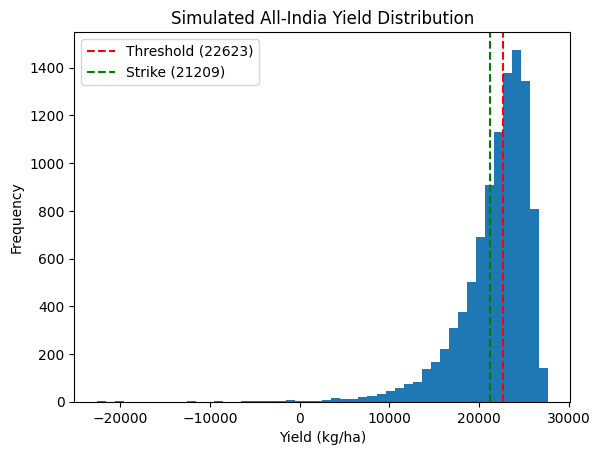

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm, norm
import matplotlib.pyplot as plt

# 1. Load national/regional rainfall data (monthly or seasonal)
# Example: 'national_rainfall.csv' with columns 'Jun', 'Jul', 'Aug', 'Sep'
df_national = pd.read_csv('/content/merged_yield_rainfall_1966_2010.csv')

# **Add this line to inspect column names**
print("Columns in df_national:", df_national.columns.tolist())

# 2. Calculate seasonal monsoon average
# **Replace ['Jun', 'Jul', 'Aug', 'Sep'] with the actual column names found above**
# For example, if your columns are named 'Rain_June', 'Rain_July', 'Rain_Aug', 'Rain_Sep':
# monsoon_rain = df_national[['Rain_June', 'Rain_July', 'Rain_Aug', 'Rain_Sep']].mean(axis=1)
monsoon_rain = df_national[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1) # <-- Keep this line for now, but change if needed

# 3. Fit distribution
shape, loc, scale = lognorm.fit(monsoon_rain, floc=0)
mu = np.log(scale)
sigma = shape
print(f"Fitted log-normal params: μ={mu:.2f}, σ={sigma:.2f}")

# 4. Simulate rainfall for the entire country
np.random.seed(42)
simulated_rain = lognorm.rvs(s=sigma, scale=np.exp(mu), size=10_000)

# 5. Use national/regional yield data for regression
# Example: average yield at the national level
# If you have a regression model, use it; otherwise, assume a baseline yield

# Example: assume a baseline yield (replace with your model)
# You need to define 'intercept', 'slope', and 'other_terms' or use a different yield prediction method
# Based on another code block, you might want to use a similar regression approach:
# Predict Yield for a representative year (e.g., 2010 or the last year in your data)
# Using coefficients from another cell: const = -27360.44, coef_rice_area = 0.0744, coef_year = 27.6742
# You might need average area for a specific year or an average across years
avg_area = df_national['RICE AREA (1000 ha)'].mean() # Using mean area
representative_year = 2010 # Or the last year of your data
S0_baseline = -27360.44 + 0.0744 * avg_area + 27.6742 * representative_year
print(f"Baseline Yield (S0_baseline): {S0_baseline:.2f} kg/ha")

# Define regression coefficients for rainfall effect
# Based on another cell, the coefficient for rainfall (per 1000mm) is -2.73e4
rainfall_coef_per_1000mm = -2.73e4
rainfall_coef_per_mm = rainfall_coef_per_1000mm / 1000 # Convert to effect per mm

# 6. Predict yields based on simulated rainfall
# Assuming a linear relationship where simulated_rain affects yield deviation from baseline
# This is a simplified approach; a more robust model might be needed.
simulated_yields = S0_baseline + rainfall_coef_per_mm * simulated_rain # Simplified model

# 7. Compute insurance metrics
# Use the calculated baseline yield for the strike price
X = 0.75 * S0_baseline # strike at 75% of baseline yield
# Use the calculated baseline yield for the threshold
threshold = 0.80 * S0_baseline # payout threshold at 80% of baseline yield


payoff = np.where(
    simulated_yields < threshold,
    np.maximum(0, X - simulated_yields),
    0
)

discount_rate = 0.05
T = 1
discounted_payoff = payoff * np.exp(-discount_rate * T)
average_payoff = np.mean(discounted_payoff)
payout_prob = np.mean(simulated_yields < threshold) * 100

# 8. Results
print(f"\nSimulation Results:")
print(f"Baseline Yield (S0): {S0_baseline:.2f} kg/ha")
print(f"Payout threshold: {threshold:.2f} kg/ha")
print(f"Average discounted payoff: ₹{average_payoff:.2f}/ha")
print(f"Payout probability: {payout_prob:.1f}%")

# Optional: visualize
plt.hist(simulated_yields, bins=50)
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.0f})')
plt.axvline(X, color='g', linestyle='--', label=f'Strike ({X:.0f})')
plt.title('Simulated All-India Yield Distribution')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Just seeing the 2026 yield distribution

Columns in df_national: ['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
Fitted log-normal params: μ=5.31, σ=0.57
Baseline yield (S0): 28279.21 kg/ha

--- 2026 All-India Yield and Insurance Prediction ---
Predicted 2026 Expected Yield: 21795.87 kg/ha
Strike (75% of baseline): 21209.41 kg/ha
Threshold for payout (80% of baseline): 22623.37 kg/ha
Expected discounted payout: ₹1176.74 per hectare
Payout probability in 2026: 48.2%


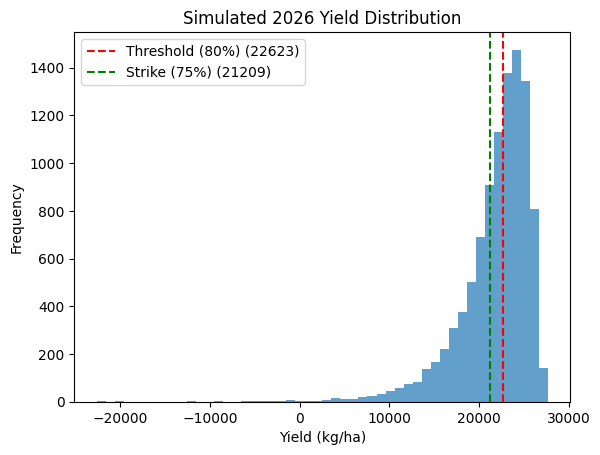

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm
import matplotlib.pyplot as plt

# 1. Load your data
df_national = pd.read_csv('/content/merged_yield_rainfall_1966_2010.csv')
print("Columns in df_national:", df_national.columns.tolist())

# 2. Calculate seasonal monsoon average
# Change column names if needed, based on your actual CSV
monsoon_rain = df_national[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1)

# 3. Fit log-normal distribution to historical monsoon rainfall
shape, loc, scale = lognorm.fit(monsoon_rain, floc=0)
mu = np.log(scale)
sigma = shape
print(f"Fitted log-normal params: μ={mu:.2f}, σ={sigma:.2f}")

# 4. Simulate rainfall for 2026
np.random.seed(42)
simulated_rain_2026 = lognorm.rvs(s=sigma, scale=np.exp(mu), size=10_000)

# 5. Use your regression model coefficients
# Replace with your actual regression coefficients
# Example coefficients from your previous code:
intercept = -27360.44
avg_area = df_national['RICE AREA (1000 ha)'].mean()
representative_year = 2010  # or last year in your data

# Regression for baseline yield
S0_baseline = intercept + 0.0744 * avg_area + 27.6742 * representative_year
print(f"Baseline yield (S0): {S0_baseline:.2f} kg/ha")

# Effect of rainfall on yield (per mm)
rainfall_coef_per_1000mm = -2.73e4
rainfall_coef_per_mm = rainfall_coef_per_1000mm / 1000

# 6. Predict yields for 2026 based on simulated rainfall
simulated_yields_2026 = S0_baseline + rainfall_coef_per_mm * simulated_rain_2026

# 7. Calculate insurance thresholds
X_2026 = 0.75 * S0_baseline
threshold_2026 = 0.80 * S0_baseline

# Payoff calculation
payoff_2026 = np.where(
    simulated_yields_2026 < threshold_2026,
    np.maximum(0, X_2026 - simulated_yields_2026),
    0
)

# Discounted expected payout
discount_rate = 0.05
T = 1
discounted_payoff_2026 = payoff_2026 * np.exp(-discount_rate * T)
expected_payout_2026 = np.mean(discounted_payoff_2026)
payout_prob_2026 = np.mean(simulated_yields_2026 < threshold_2026) * 100

# 8. Display results
print(f"\n--- 2026 All-India Yield and Insurance Prediction ---")
print(f"Predicted 2026 Expected Yield: {np.mean(simulated_yields_2026):.2f} kg/ha")
print(f"Strike (75% of baseline): {X_2026:.2f} kg/ha")
print(f"Threshold for payout (80% of baseline): {threshold_2026:.2f} kg/ha")
print(f"Expected discounted payout: ₹{expected_payout_2026:.2f} per hectare")
print(f"Payout probability in 2026: {payout_prob_2026:.1f}%")

# Optional visualization
plt.hist(simulated_yields_2026, bins=50, alpha=0.7)
plt.axvline(threshold_2026, color='r', linestyle='--', label=f'Threshold (80%) ({threshold_2026:.0f})')
plt.axvline(X_2026, color='g', linestyle='--', label=f'Strike (75%) ({X_2026:.0f})')
plt.title('Simulated 2026 Yield Distribution')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

India 2026 premium estimation roughly

In [ ]:
# Re-import necessary libraries after kernel reset
import pandas as pd
import numpy as np
from scipy.stats import lognorm, norm

# Load the dataset (ensure correct path)
file_path = "/content/merged_yield_rainfall_1966_2015.csv"
df = pd.read_csv(file_path)

# Extract monsoon rainfall data
rainfall_data = df[['JUN', 'JUL', 'AUG', 'SEP']].values.flatten()
rainfall_data = rainfall_data[~np.isnan(rainfall_data)]
rainfall_data = rainfall_data[rainfall_data > 0] # Ensure positive data for log-normal fit

# Empirical stats (Optional, for reporting)
emp_mean = np.mean(rainfall_data)
emp_median = np.median(rainfall_data)
emp_min = np.min(rainfall_data)
emp_max = np.max(rainfall_data)

# Estimate log-normal parameters using fit()
# fit() returns shape, loc, scale. We fix loc=0 for a standard log-normal.
shape_fitted, loc_fitted, scale_fitted = lognorm.fit(rainfall_data, floc=0)

# The parameters for lognorm.rvs are s=shape and scale=exp(mu) or the scale directly.
# With floc=0, shape_fitted is sigma and scale_fitted is exp(mu).
sigma_fitted = shape_fitted
mu_fitted = np.log(scale_fitted) # Calculate mu from the fitted scale

# Simulate 10,000 rainfall values for 2026 using fitted parameters
np.random.seed(42)
# Pass the fitted shape (sigma_fitted) and scale (scale_fitted) directly to rvs
simulated_rain = lognorm.rvs(s=sigma_fitted, scale=scale_fitted, size=10_000)


# Use regional/historical regression coefficients
# Replace with your actual coefficients if different
# Example: from your previous code
intercept = -27360.44
avg_area = df['RICE AREA (1000 ha)'].mean()
representative_year = 2010  # or last year in your data

# Predict baseline yield (S0) for 2026
# Ensure the year for baseline calculation is consistent if used in strike/threshold logic
# If S0 is meant to be a baseline based on historical data, use 2010 or the last data year.
# If S0 is meant to be the *expected* yield for 2026 *before* considering rainfall deviation, use 2026.
# Based on previous cells, S0 seems to be the baseline derived from the regression, which might be
# based on the last year of historical data or an average. Let's use 2010 as in prior cells
# unless the intention is to use 2026 here as the expected mean yield for 2026.
# Let's stick to using 2010 as the representative year for S0 baseline calculation
# to align with previous cells, but note that this S0 is NOT the expected yield for 2026
# in the simulation, which includes rainfall variability. The expected yield from simulation
# will be np.mean(simulated_yields).
S0_baseline_2010 = intercept + 0.0744 * avg_area + 27.6742 * representative_year

# Calculate expected yield for 2026 based on the *mean* simulated rainfall
# The expected yield for 2026 in the simulation would be S0_baseline_2010 + rain_coefficient_per_mm * np.mean(simulated_rain)
# This is usually close to S0_baseline_2010 if the mean of simulated_rain is near zero
# in the context of the regression model's independent variable. However, simulated_rain
# is actual rainfall values, not deviations. The regression implies yield = f(Year, Area, Rainfall).
# Let's adjust the model prediction to reflect the structure from ipython-input-18
# where yield = regression_terms + rainfall_effect.

# Using the structure from ipython-input-18:
# simulated_yields = regression_terms_for_2026 - 2.73e4 * (simulated_rain / 1000)
# regression_terms_for_2026 = intercept + 0.0744 * avg_area + 27.6742 * 2026
regression_terms_2026 = intercept + 0.0744 * avg_area + 27.6742 * 2026

# Effect of rainfall on yield (per mm), based on -2.73e4 per 1000mm
rain_coefficient_per_1000mm = -2.73e4
rain_coefficient_per_mm = rain_coefficient_per_1000mm / 1000

# Predict yields for 2026 based on simulated rainfall
# Assuming the rainfall term in the original regression was applied to actual rainfall
simulated_yields = regression_terms_2026 + rain_coefficient_per_mm * simulated_rain

# Let's redefine S0 as the expected yield for 2026 BEFORE rainfall variation,
# calculated using the regression with the mean area and the target year 2026.
S0_expected_2026 = intercept + 0.0744 * avg_area + 27.6742 * 2026


# Insurance parameters
# Define Strike (X) and Threshold based on the *expected* yield for the target year (2026)
X = 0.50 * S0_expected_2026  # Strike yield
threshold = 0.60 * S0_expected_2026  # Payout threshold

# Calculate payoff
payoff = np.where(simulated_yields < threshold, np.maximum(0, X - simulated_yields), 0)

# Discounted payout
discount_rate = 0.05
T = 1
discounted_payoff = payoff * np.exp(-discount_rate * T)

# Expected payout and payout probability
average_payoff = np.mean(discounted_payoff)
payout_prob = np.mean(simulated_yields < threshold) * 100

# Black-Scholes style premium calculation
# Note: Black-Scholes assumes a normal distribution for log-returns (implying log-normal asset price)
# and constant volatility. Applying it directly to yield with parameters derived from rainfall
# simulation is an approximation. sigma here refers to the volatility of the UNDERLYING process,
# which isn't directly estimated from the simulated yield distribution's standard deviation
# in the same way Black-Scholes implies.
# Using the sigma fitted to rainfall might not be appropriate here.
# A more consistent approach for Black-Scholes would be to estimate the volatility of YIELD,
# perhaps from historical yield data or from the standard deviation of the simulated yields.
# Let's calculate the standard deviation of the simulated yields as a proxy for volatility
# in the Black-Scholes context, understanding this is an approximation.
yield_volatility_proxy = np.std(simulated_yields) / np.mean(simulated_yields) # Coefficient of Variation as volatility?
# Or simply use the std dev of simulated yields
yield_std_dev = np.std(simulated_yields)

# Re-evaluating Black-Scholes application: Black-Scholes is for geometric Brownian motion, often applied to prices.
# Applying it to yield directly requires careful justification of the underlying stochastic process.
# If the simulation approach is preferred, the Monte Carlo average payoff IS the estimated premium.
# The Black-Scholes part here might be for comparison or if yield is modeled as log-normal itself.
# If yield is modeled as log-normal: need mu_yield and sigma_yield for log-yield.
# If yield is modeled as having rainfall effect on a baseline: the std dev of the simulated yields reflects the total variability.
# Let's use the simulation result as the primary premium estimate. The Black-Scholes formula needs S0 (current/expected), X (strike), r, sigma (volatility of S), T.
# Using S0_expected_2026 as the forward yield and the std dev of simulated yields as a measure of total volatility:
# This is still an approximation as Black-Scholes assumes volatility of the *log* of the underlying.
# Let's calculate the standard deviation of the LOG of the positive simulated yields.
positive_simulated_yields = simulated_yields[simulated_yields > 0]
if len(positive_simulated_yields) > 1:
    log_yield_std_dev = np.std(np.log(positive_simulated_yields))
else:
    log_yield_std_dev = np.nan # Cannot calculate if not enough positive data

# Black-Scholes using S0_expected_2026 and log_yield_std_dev (if applicable)
# This assumes yield follows a log-normal process driven by this volatility.
if not np.isnan(log_yield_std_dev):
    d1_bs = (np.log(S0_expected_2026 / X) + (discount_rate + 0.5 * log_yield_std_dev**2) * T) / (log_yield_std_dev * np.sqrt(T))
    d2_bs = d1_bs - log_yield_std_dev * np.sqrt(T)
    # Using norm.cdf(-d2_bs) and norm.cdf(-d1_bs) for a put option premium
    premium_bs = X * np.exp(-discount_rate * T) * norm.cdf(-d2_bs) - S0_expected_2026 * norm.cdf(-d1_bs)
else:
    premium_bs = np.nan # Cannot calculate BS premium


# Prepare summary dataframe
df_summary = pd.DataFrame({
    "Empirical Mean (Rainfall)": [emp_mean],
    "Empirical Median (Rainfall)": [emp_median],
    "Minimum Rainfall": [emp_min],
    "Maximum Rainfall": [emp_max],
    "Fitted μ (Log-Normal)": [mu_fitted],
    "Fitted σ (Log-Normal)": [sigma_fitted],
    "Expected Yield 2026 (S₀)": [S0_expected_2026],
    "Strike Yield (X)": [X],
    "Payout Threshold (0.8×S₀)": [threshold],
    "Expected Discounted Payout (₹/ha)": [average_payoff], # Monte Carlo estimate
    "Payout Probability (%)": [payout_prob],
    "Theoretical Premium (BS, ₹/ha)": [premium_bs] # Black-Scholes estimate (approx)
})

# Create simulation dataframe
df_simulation = pd.DataFrame({
    "Simulated Rainfall (mm)": simulated_rain,
    "Predicted Yield (kg/ha)": simulated_yields,
    "Payoff (₹/ha)": payoff,
    "Discounted Payoff (₹/ha)": discounted_payoff
})

# Save to Excel
output_path = "India_2026_Insurance_Prediction1.xlsx" # Changed filename slightly for clarity
with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    df_simulation.to_excel(writer, sheet_name='Simulation Data', index=False)

print(f"Results saved to: {output_path}")

Results saved to: India_2026_Insurance_Prediction1.xlsx


Prediction of yield and price using random forest regressor 2025

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Encode categorical state
le = LabelEncoder()
df['State_encoded'] = le.fit_transform(df['State'])

# Features and targets
X = df[['Year', 'State_encoded']]
y_price = df['Price (₹/kg)']
y_yield = df['Yield (kg/ha)']

# Train model for Price
model_price = RandomForestRegressor()
model_price.fit(X, y_price)

# Train model for Yield
model_yield = RandomForestRegressor()
model_yield.fit(X, y_yield)

# Prepare input for 2025
states = df['State'].unique()
future_data = pd.DataFrame({
    'Year': [2025]*len(states),
    'State_encoded': le.transform(states)
})

# Predict
predicted_price = model_price.predict(future_data)
predicted_yield = model_yield.predict(future_data)

# Combine and show results
result = pd.DataFrame({
    'State': states,
    'Predicted Price (₹/kg) - 2025': predicted_price,
    'Predicted Yield (kg/ha) - 2025': predicted_yield
})

print(result)


              State  Predicted Price (₹/kg) - 2025  \
0             Bihar                        32.4180   
1      Chhattisgarh                        34.2252   
2  Himachal Pradesh                        25.1781   
3         Jharkhand                        28.0268   
4            Kerala                        33.2375   
5            Orissa                        28.9759   
6            Punjab                        32.6487   
7        Tamil Nadu                        25.5683   
8         Telengana                        28.8247   
9       Uttarakhand                        28.8572   

   Predicted Yield (kg/ha) - 2025  
0                       2047.0889  
1                       2391.1313  
2                       2541.0893  
3                       2312.4040  
4                       3195.9434  
5                       2462.6351  
6                       8301.1210  
7                       2146.0996  
8                       2605.4659  
9                       2964.6504  


Prediction using random forest regressors

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_excel("/content/rice_data_combined.xlsx")  # Ensure your CSV is in the same directory or give full path

# Encode 'State' using LabelEncoder
le = LabelEncoder()
df['State_encoded'] = le.fit_transform(df['State'])

# Features (X) and Targets (y)
X = df[['Year', 'State_encoded']]
y_price = df['Price (₹/kg)']
y_yield = df['Yield (kg/ha)']

# Train Random Forest model for Price prediction
model_price = RandomForestRegressor(n_estimators=100, random_state=42)
model_price.fit(X, y_price)

# Train Random Forest model for Yield prediction
model_yield = RandomForestRegressor(n_estimators=100, random_state=42)
model_yield.fit(X, y_yield)

# Generate prediction input for 2025 for all states
states = df['State'].unique()
future_df = pd.DataFrame({
    'Year': [2025] * len(states),
    'State': states
})
future_df['State_encoded'] = le.transform(future_df['State'])

# Predict Price and Yield for 2025
X_future = future_df[['Year', 'State_encoded']]
future_df['Predicted_Price_₹/kg_2025'] = model_price.predict(X_future)
future_df['Predicted_Yield_kg/ha_2025'] = model_yield.predict(X_future)

# Final result
print(future_df[['State', 'Predicted_Price_₹/kg_2025', 'Predicted_Yield_kg/ha_2025']])


              State  Predicted_Price_₹/kg_2025  Predicted_Yield_kg/ha_2025
0             Bihar                    32.3253                   2068.5573
1      Chhattisgarh                    34.1456                   2398.6376
2  Himachal Pradesh                    25.4538                   2545.5816
3         Jharkhand                    28.1319                   2324.7194
4            Kerala                    33.1341                   3214.9950
5            Orissa                    28.5150                   2457.2848
6            Punjab                    32.9823                   8321.4304
7        Tamil Nadu                    25.5296                   2172.9274
8         Telengana                    28.7134                   2583.2033
9       Uttarakhand                    28.8714                   2962.1877


Using arima to forecast yield and price statewise for 2025

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")  # to suppress convergence warnings

# Load data
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Prepare structure to collect forecasts
predictions = []

# Get unique states
states = df['State'].unique()

# Forecasting loop
for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    # Ensure enough data
    if len(state_df) < 8:
        continue

    years = state_df['Year'].values
    price_series = state_df['Price (₹/kg)'].reset_index(drop=True)
    yield_series = state_df['Yield (kg/ha)'].reset_index(drop=True)

    # Price Forecast
    try:
        price_model = ARIMA(price_series, order=(1,1,1))
        price_fit = price_model.fit()
        price_forecast = price_fit.forecast(steps=2)
        price_2025 = price_forecast.iloc[1]
    except:
        price_2025 = None

    # Yield Forecast
    try:
        yield_model = ARIMA(yield_series, order=(1,1,1))
        yield_fit = yield_model.fit()
        yield_forecast = yield_fit.forecast(steps=2)
        yield_2025 = yield_forecast.iloc[1]
    except:
        yield_2025 = None

    # Save
    predictions.append({
        'State': state,
        'Predicted Price (₹/kg) for 2025': round(price_2025, 2) if price_2025 else 'Error',
        'Predicted Yield (kg/ha) for 2025': round(yield_2025, 2) if yield_2025 else 'Error'
    })

# Final DataFrame
result_df = pd.DataFrame(predictions)
print(result_df)

# Optionally save to CSV
# result_df.to_csv("rice_2025_forecast_ARIMA_all_states.csv", index=False)


              State  Predicted Price (₹/kg) for 2025  \
0             Bihar                            34.11   
1      Chhattisgarh                            35.78   
2  Himachal Pradesh                            25.55   
3         Jharkhand                            29.71   
4            Kerala                            35.03   
5            Orissa                            30.02   
6            Punjab                            34.09   
7        Tamil Nadu                            26.05   
8         Telengana                            30.09   
9       Uttarakhand                            29.88   

   Predicted Yield (kg/ha) for 2025  
0                           2125.45  
1                           2288.55  
2                           2598.65  
3                           2239.96  
4                           3221.39  
5                           2477.85  
6                           8331.53  
7                           2039.72  
8                           2593.60  
9  

Rice yield forecast using state each with graph

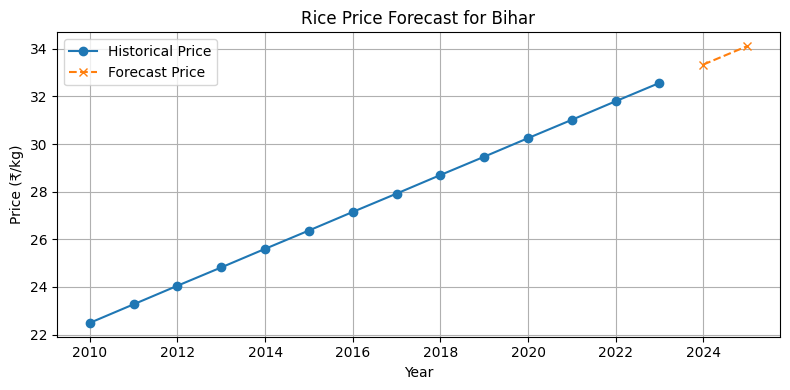

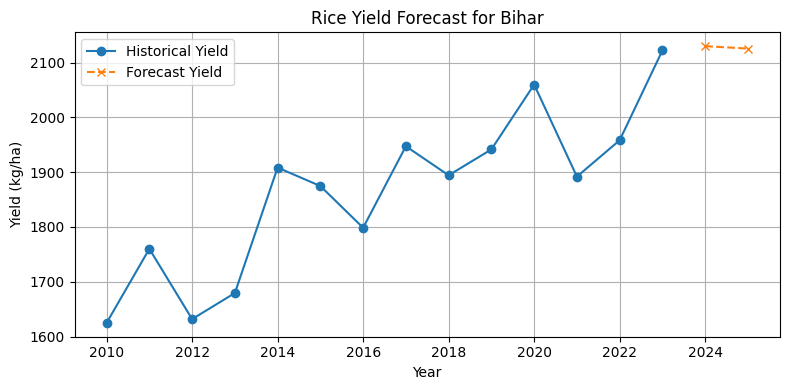

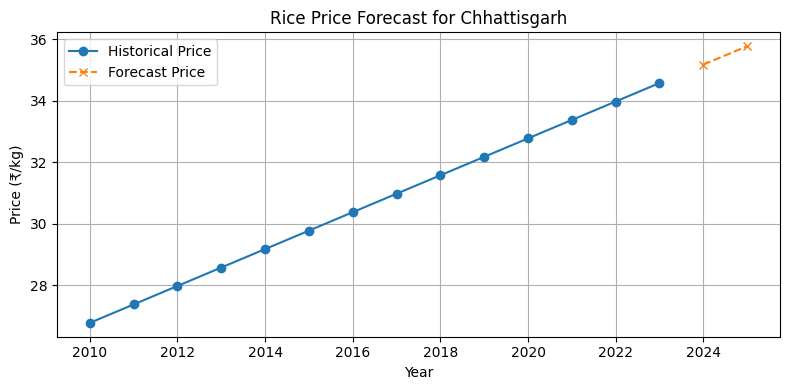

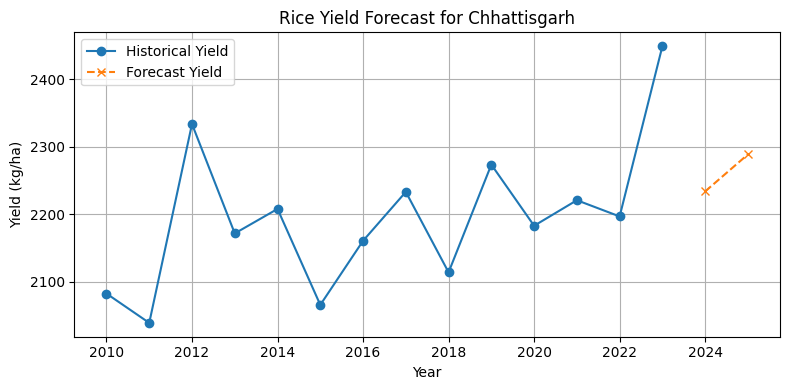

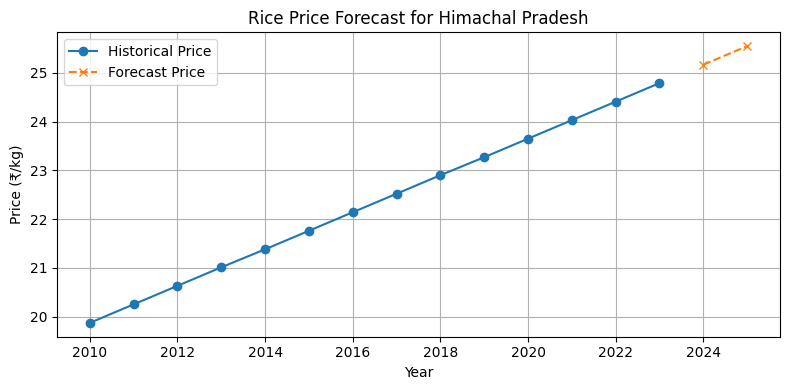

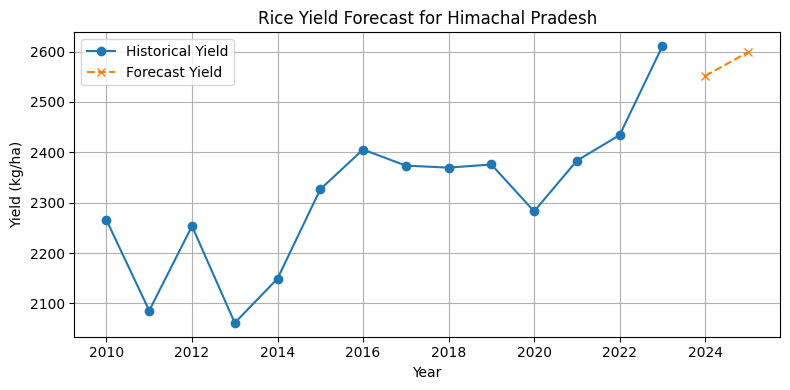

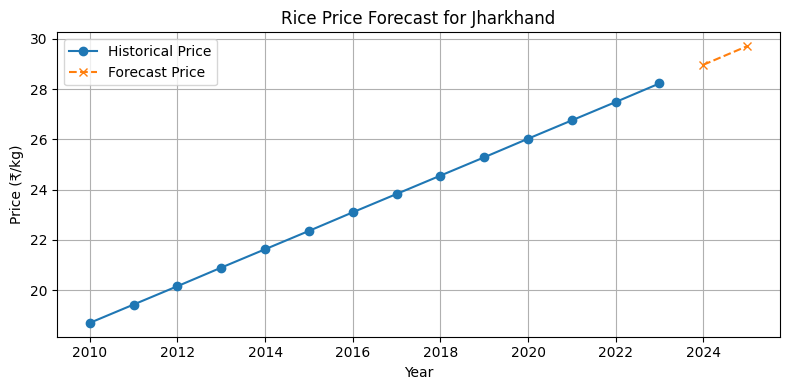

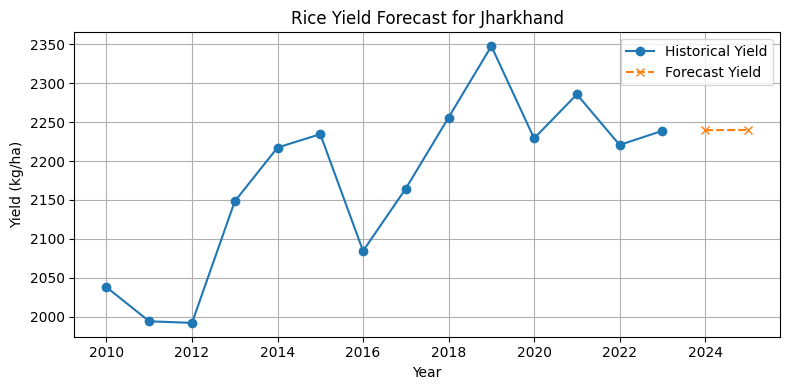

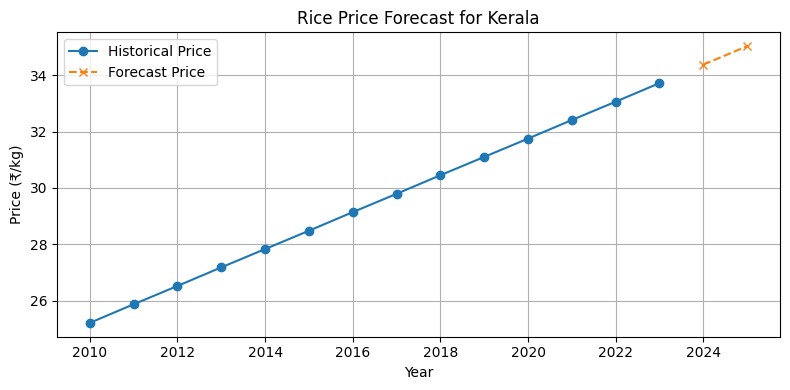

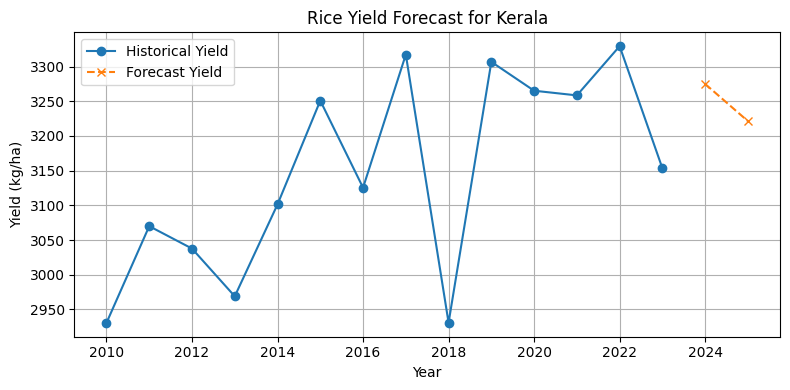

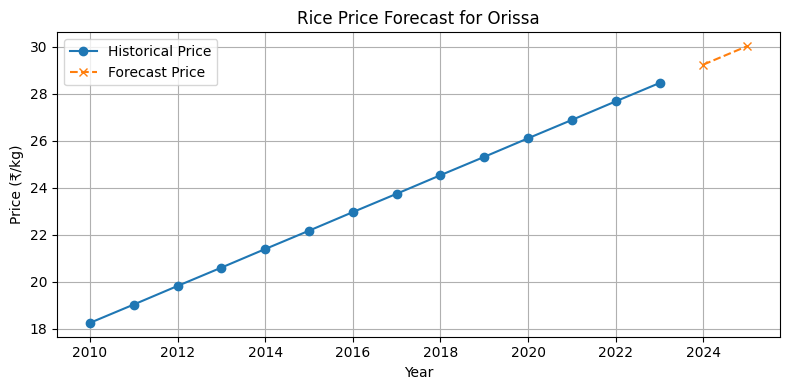

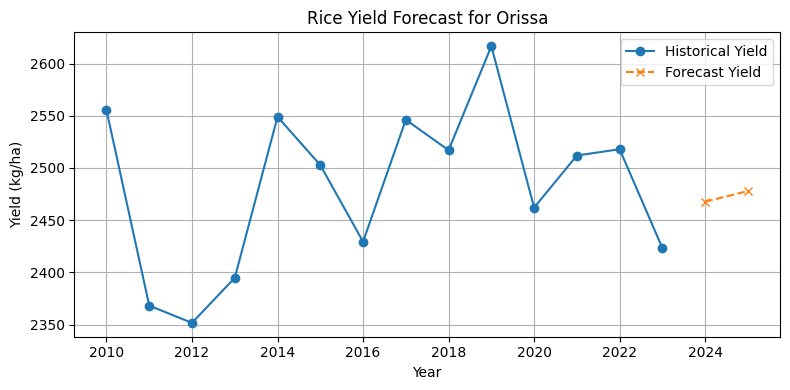

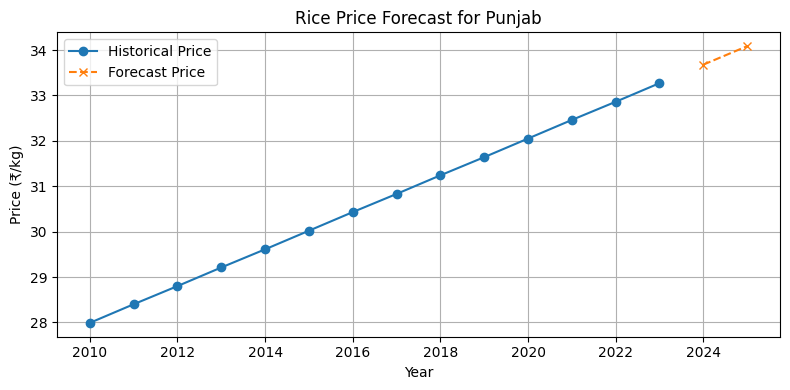

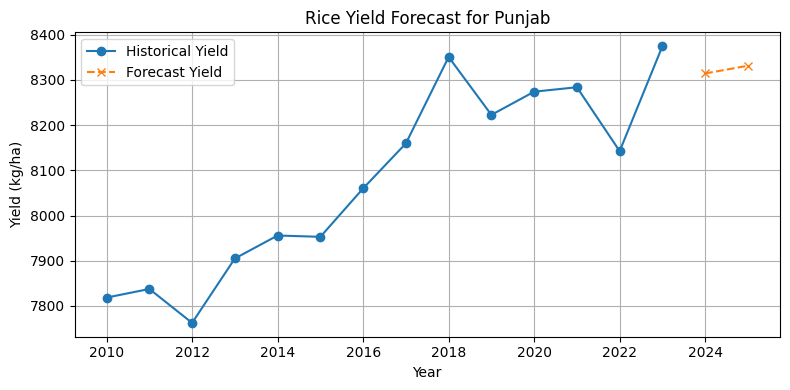

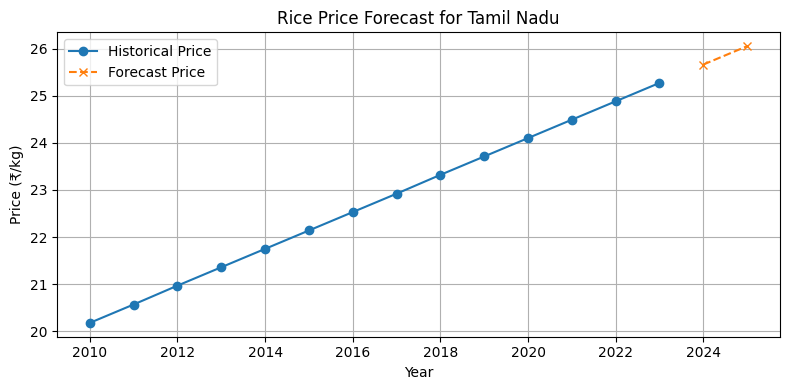

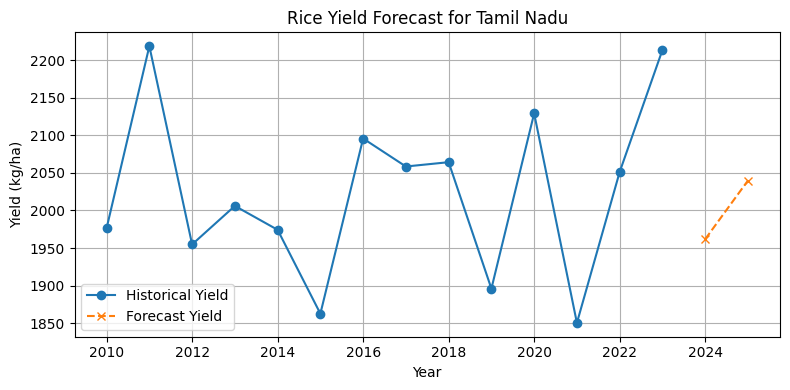

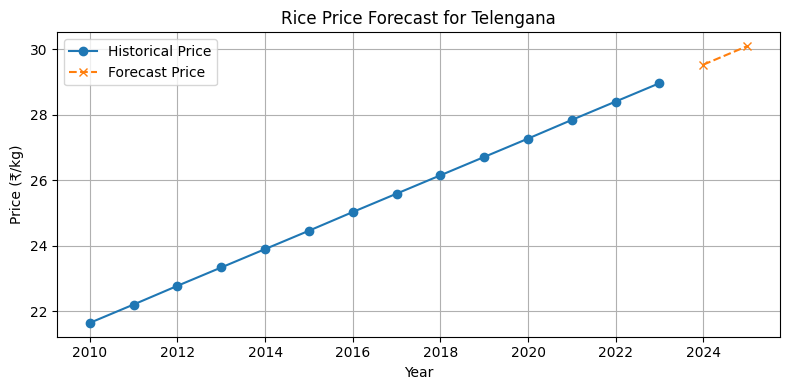

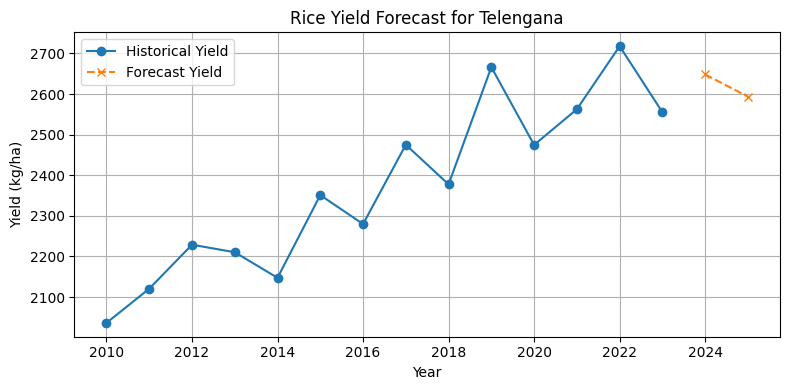

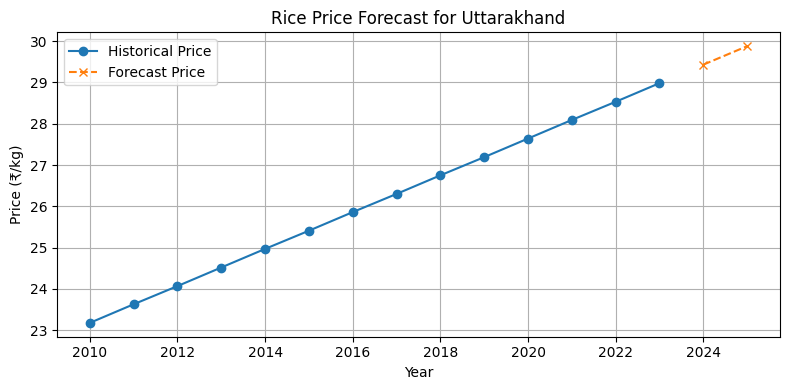

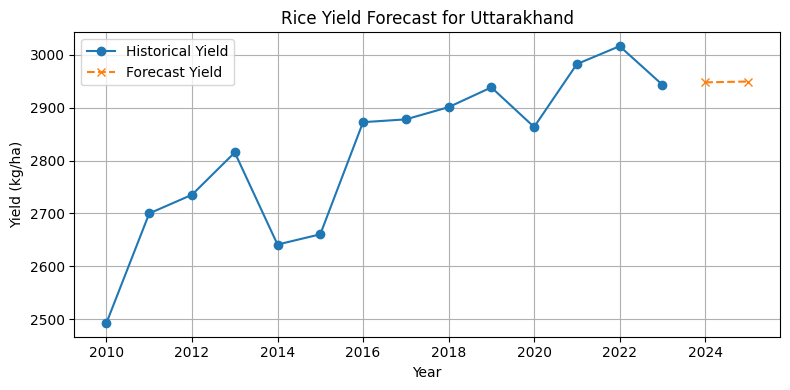

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Unique states
states = df['State'].unique()

# Loop through each state
for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    if len(state_df) < 8:
        continue  # Skip if not enough data

    # Reset indices
    years = state_df['Year'].values
    price_series = state_df['Price (₹/kg)'].reset_index(drop=True)
    yield_series = state_df['Yield (kg/ha)'].reset_index(drop=True)

    # ------------------- Price Forecast -------------------
    try:
        model_price = ARIMA(price_series, order=(1,1,1))
        model_price_fit = model_price.fit()
        forecast_price = model_price_fit.forecast(steps=2)

        # Plot
        plt.figure(figsize=(8, 4))
        plt.plot(years, price_series, label='Historical Price', marker='o')
        future_years = [years[-1] + 1, years[-1] + 2]
        plt.plot(future_years, forecast_price, label='Forecast Price', linestyle='--', marker='x')
        plt.title(f"Rice Price Forecast for {state}")
        plt.xlabel("Year")
        plt.ylabel("Price (₹/kg)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except:
        print(f"Could not forecast price for {state}")

    # ------------------- Yield Forecast -------------------
    try:
        model_yield = ARIMA(yield_series, order=(1,1,1))
        model_yield_fit = model_yield.fit()
        forecast_yield = model_yield_fit.forecast(steps=2)

        # Plot
        plt.figure(figsize=(8, 4))
        plt.plot(years, yield_series, label='Historical Yield', marker='o')
        future_years = [years[-1] + 1, years[-1] + 2]
        plt.plot(future_years, forecast_yield, label='Forecast Yield', linestyle='--', marker='x')
        plt.title(f"Rice Yield Forecast for {state}")
        plt.xlabel("Year")
        plt.ylabel("Yield (kg/ha)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except:
        print(f"Could not forecast yield for {state}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Parameters
n_steps = 3  # lookback (use last 3 years to predict next)
epochs = 10

# Function to create sequences
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

# For storing predictions
results = []

# Unique states
states = df['State'].unique()

for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    if len(state_df) <= n_steps:
        continue  # not enough data

    for target_col in ['Price (₹/kg)', 'Yield (kg/ha)']:
        # Normalize the target
        scaler = MinMaxScaler()
        scaled_target = scaler.fit_transform(state_df[[target_col]])

        # Create sequences
        X, y = create_sequences(scaled_target, n_steps)
        X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM input shape

        # Define LSTM model
        model = Sequential()
        model.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
        model.add(Dense(1))
        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

        # Train
        model.fit(X, y, epochs=epochs, verbose=0)

        # Prepare last known window to predict next
        last_sequence = scaled_target[-n_steps:].reshape((1, n_steps, 1))
        pred_scaled = model.predict(last_sequence)[0][0]
        pred_actual = scaler.inverse_transform([[pred_scaled]])[0][0]

        results.append({
            'State': state,
            'Variable': target_col,
            'Predicted_2025': round(pred_actual, 2)
        })

# Convert to DataFrame
result_df = pd.DataFrame(results)
price_df = result_df[result_df['Variable'] == 'Price (₹/kg)'][['State', 'Predicted_2025']].rename(columns={'Predicted_2025': 'Price (₹/kg) - 2025'})
yield_df = result_df[result_df['Variable'] == 'Yield (kg/ha)'][['State', 'Predicted_2025']].rename(columns={'Predicted_2025': 'Yield (kg/ha) - 2025'})

# Merge results
final_result = pd.merge(price_df, yield_df, on='State')
print(final_result)

# Optionally save:
# final_result.to_csv("rice_price_yield_2025_lstm.csv", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
              State  Price (₹/kg) - 2025  Yield (kg/ha) - 2025
0             Bihar                34.92               2137.24
1      Chhattisgarh                33.97               2309.81
2  Himachal Pradesh                24.86               2574.86
3         Jharkhand                31.85               2342.65
4            Kerala                36.05               3315.29
5            Orissa                30

Forecasting price and yield using nnar and arimax

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Helper function: convert residuals to supervised learning format
def make_supervised(data, lag=3):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Final result container
final_results = []

# Variables to predict
targets = ['Price (₹/kg)', 'Yield (kg/ha)']
states = df['State'].unique()

for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    for target_col in targets:
        if len(state_df) < 7:
            continue  # Not enough data

        # Target and exogenous variable
        y = state_df[target_col].values
        exog = state_df['Year'].values.reshape(-1, 1)

        try:
            # Step 1: ARIMAX
            arimax_model = SARIMAX(endog=y, exog=exog, order=(1,1,1))
            arimax_fit = arimax_model.fit(disp=False)
            arimax_forecast = arimax_fit.forecast(steps=2, exog=np.array([[2024], [2025]]))
            arimax_2025 = arimax_forecast[1]

            # Step 2: Residuals
            residuals = y[1:] - arimax_fit.fittedvalues[1:]

            # Step 3: NNAR (NN)
            scaler = MinMaxScaler()
            res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))

            X_nn, y_nn = make_supervised(res_scaled, lag=3)
            if len(X_nn) == 0:
                raise ValueError("Not enough residuals for NN")

            model = Sequential()
            model.add(Dense(32, input_dim=3, activation='relu'))
            model.add(Dense(1))
            model.compile(optimizer='adam', loss='mse')
            model.fit(X_nn, y_nn, epochs=10, verbose=0)

            # Predict next residual
            last_res = res_scaled[-3:].reshape(1, 3)
            pred_res_scaled = model.predict(last_res)[0][0]
            pred_res = scaler.inverse_transform([[pred_res_scaled]])[0][0]

            # Step 4: Final hybrid prediction
            hybrid_2025 = arimax_2025 + pred_res

            final_results.append({
                'State': state,
                'Variable': target_col,
                'ARIMAX_2025': round(arimax_2025, 2),
                'NNAR_residual_2025': round(pred_res, 2),
                'Hybrid_2025': round(hybrid_2025, 2)
            })

        except Exception as e:
            print(f"Skipping {state} - {target_col}: {e}")

# Convert to DataFrame
result_df = pd.DataFrame(final_results)

# Pivot to show final hybrid forecasts side by side
pivot_df = result_df.pivot(index='State', columns='Variable', values='Hybrid_2025')
pivot_df.columns = [f'2025 Forecast - {col}' for col in pivot_df.columns]
pivot_df = pivot_df.reset_index()

# Show final table
print(pivot_df)

# Optional:


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
              State  2025 Forecast - Price (₹/kg)  \
0             Bihar                         34.12   
1      Chhattisgarh                         35.78   
2  Himachal Pradesh                         25.54   
3         Jharkhand       

Predicted yield using lstm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Parameters
n_steps = 3  # lookback (use last 3 years to predict next)
epochs = 10

# Function to create sequences
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

# For storing predictions
results = []

# Unique states
states = df['State'].unique()

for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    if len(state_df) <= n_steps:
        continue  # not enough data

    for target_col in ['Price (₹/kg)', 'Yield (kg/ha)']:
        # Normalize the target
        scaler = MinMaxScaler()
        scaled_target = scaler.fit_transform(state_df[[target_col]])

        # Create sequences
        X, y = create_sequences(scaled_target, n_steps)
        X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM input shape

        # Define LSTM model
        model = Sequential()
        model.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
        model.add(Dense(1))
        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

        # Train
        model.fit(X, y, epochs=epochs, verbose=0)

        # Prepare last known window to predict next
        last_sequence = scaled_target[-n_steps:].reshape((1, n_steps, 1))
        pred_scaled = model.predict(last_sequence)[0][0]
        pred_actual = scaler.inverse_transform([[pred_scaled]])[0][0]

        results.append({
            'State': state,
            'Variable': target_col,
            'Predicted_2025': round(pred_actual, 2)
        })

# Convert to DataFrame
result_df = pd.DataFrame(results)
price_df = result_df[result_df['Variable'] == 'Price (₹/kg)'][['State', 'Predicted_2025']].rename(columns={'Predicted_2025': 'Price (₹/kg) - 2025'})
yield_df = result_df[result_df['Variable'] == 'Yield (kg/ha)'][['State', 'Predicted_2025']].rename(columns={'Predicted_2025': 'Yield (kg/ha) - 2025'})

# Merge results
final_result = pd.merge(price_df, yield_df, on='State')
print(final_result)

# Optionally save:
# final_result.to_csv("rice_price_yield_2025_lstm.csv", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
              State  Price (₹/kg) - 2025  Yield (kg/ha) - 2025
0             Bihar                36.20               2148.26
1      Chhattisgarh                37.40               2300.10
2  Himachal Pradesh                25.53               2521.27
3         Jharkhand                32.21               2297.65
4            Kerala                29.73               3303.22
5            Orissa                31

Predicted yield 2026 lstm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Parameters
n_steps = 3  # Use last 3 years to predict next
epochs = 10  # Number of epochs for training

# Function to create sequences
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

# Unique states
states = df['State'].unique()

# Store predictions for 2026
results_2026 = []

for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    # Skip if insufficient data
    if len(state_df) <= n_steps:
        continue

    target_col = 'Yield (kg/ha)'

    # Normalize target column
    scaler = MinMaxScaler()
    scaled_target = scaler.fit_transform(state_df[[target_col]])

    # Create sequences
    X, y = create_sequences(scaled_target, n_steps)
    X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM expects 3D input

    # Define LSTM model
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

    # Train the model
    model.fit(X, y, epochs=epochs, verbose=0)

    # Step 1: Predict Yield for 2025
    last_sequence = scaled_target[-n_steps:].reshape((1, n_steps, 1))
    pred_scaled_2025 = model.predict(last_sequence)[0][0]

    # Step 2: Predict Yield for 2026 using extended sequence
    extended_sequence = np.append(scaled_target.flatten(), pred_scaled_2025)
    new_last_seq = extended_sequence[-n_steps:].reshape((1, n_steps, 1))
    pred_scaled_2026 = model.predict(new_last_seq)[0][0]

    # Inverse transform to get actual yield prediction
    pred_actual_2026 = scaler.inverse_transform([[pred_scaled_2026]])[0][0]

    # Save the result
    results_2026.append({
        'State': state,
        'Predicted_Yield_2026 (kg/ha)': round(pred_actual_2026, 2)
    })

# Final result as DataFrame
yield_2026_df = pd.DataFrame(results_2026)

# Display
print("\nPredicted Rice Yield for 2026:")
print(yield_2026_df)

# Optionally save the results
# yield_2026_df.to_csv("predicted_yield_2026_lstm.csv", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Predicted Rice Yield for 2026:
              State  Predicted_Yield_2026 (kg/ha)
0             Bihar                       1901.50
1      Chhattisgarh                       2320.16
2  Himachal Pradesh                       2638.79
3         Jharkhand                       2320.07
4            Kerala                       3179.82
5            Orissa                       2495.59
6            Punjab                       8494.10
7        Tamil Nadu                       2114.83
8         Telengana                       2964.76
9       Uttarakhand                       3240.27


Prediction of rice yield 2026 using Arimax

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_excel("/content/rice_data_combined.xlsx")

# Target and exogenous columns
target_col = 'Yield (kg/ha)'
exog_col = 'Price (₹/kg)'  # You can change this to rainfall or other features

# Store predictions for 2026
results_arimax = []

# Unique states
states = df['State'].unique()

# Loop through each state
for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    if len(state_df) < 6:
        continue  # Not enough data

    y = state_df[target_col].values
    exog = state_df[[exog_col]].values

    try:
        # Fit ARIMAX model (you can tune the order)
        model = SARIMAX(y, exog=exog, order=(1,1,1), enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Forecast Yield for 2026 using last known exog value
        future_exog = exog[-1].reshape(1, -1)
        forecast = model_fit.forecast(steps=1, exog=future_exog)
        pred_2026 = round(float(forecast[0]), 2)

        results_arimax.append({
            'State': state,
            'Predicted_Yield_2026 (kg/ha)': pred_2026
        })

    except Exception as e:
        print(f"ARIMAX failed for {state}: {e}")
        continue

# Create DataFrame of results
yield_2026_arimax = pd.DataFrame(results_arimax)

# Show result
print("\nPredicted Rice Yield for 2026 using ARIMAX:")
print(yield_2026_arimax)

# Save if needed
# yield_2026_arimax.to_csv("predicted_yield_2026_arimax.csv", index=False)



Predicted Rice Yield for 2026 using ARIMAX:
              State  Predicted_Yield_2026 (kg/ha)
0             Bihar                       2049.77
1      Chhattisgarh                       2206.33
2  Himachal Pradesh                       2544.37
3         Jharkhand                       2281.44
4            Kerala                       3376.35
5            Orissa                       2507.10
6            Punjab                       8379.50
7        Tamil Nadu                       1993.91
8         Telengana                       2775.27
9       Uttarakhand                       3004.92


In [ ]:
# Re-import required packages after kernel reset
import pandas as pd

# Reload the uploaded Excel files
file_paths = [
    "/content/Mandi_price_data.xlsx",
    "/content/Mandi_price_data (1).xlsx",
    "/content/Mandi_price_data (2).xlsx",
    "/content/Mandi_price_data (3).xlsx",
    "/content/Mandi_price_data (4).xlsx",
    "/content/Mandi_price_data (5).xlsx",
    "/content/Mandi_price_data (6).xlsx",
    "/content/Mandi_price_data (7).xlsx",
    "/content/Mandi_price_data (8).xlsx",
    "/content/Mandi_price_data (9).xlsx",
    "/content/Mandi_price_data (10).xlsx"
]

# Read the first sheet from each Excel file and store in a list
dataframes = [pd.read_excel(fp) for fp in file_paths]

# Preview the first few rows of each file to understand structure
sample_previews = [df.head() for df in dataframes]

sample_previews
import numpy as np

# Combine all price data into one DataFrame
combined_df = pd.concat(dataframes, ignore_index=True)

# Convert dates
combined_df['Arrival Date'] = pd.to_datetime(combined_df['Arrival Date'], dayfirst=True)

# Remove rows with missing values in key columns
combined_df = combined_df.dropna(subset=['State', 'Avg price', 'Arrival Date'])

# Compute monthly average price by State
combined_df['YearMonth'] = combined_df['Arrival Date'].dt.to_period('M')
monthly_state_avg = (
    combined_df.groupby(['State', 'YearMonth'])['Avg price']
    .mean()
    .reset_index()
    .sort_values(by=['State', 'YearMonth'])
)

# Convert YearMonth back to datetime for time series analysis
monthly_state_avg['YearMonth'] = monthly_state_avg['YearMonth'].dt.to_timestamp()

print(monthly_state_avg)
from statsmodels.tsa.arima.model import ARIMA

# Store predictions in a dictionary
state_forecasts = {}

# Loop through each state
for state in monthly_state_avg['State'].unique():
    # Subset data for the state
    state_data = monthly_state_avg[monthly_state_avg['State'] == state]
    ts = state_data.set_index('YearMonth')['Avg price']

    # Fit ARIMA(1,1,1) model (simple, stable choice)
    try:
        model = ARIMA(ts, order=(1, 1, 1))
        model_fit = model.fit()

        # Forecast for 12 months (2026)
        forecast = model_fit.forecast(steps=12)
        forecast.index = pd.date_range(start='2026-01-31', periods=12, freq='M')

        # Store forecast
        state_forecasts[state] = forecast
    except:
        state_forecasts[state] = None  # model failed for this state

# Collect all forecasts into one DataFrame
forecast_df = pd.DataFrame({state: f for state, f in state_forecasts.items() if f is not None})
forecast_df = forecast_df.round(2)
forecast_df.head()
print(forecast_df)
